<div align="center">

# 🩺 Diabetes Readmission Prediction System  
### *From Data Analysis to Machine Learning Deployment*

<img src="https://img.shields.io/badge/Dataset-101K%20Patients-blue?style=for-the-badge">
<img src="https://img.shields.io/badge/Focus-Healthcare%20AI-success?style=for-the-badge">
<img src="https://img.shields.io/badge/Project-ML%20%26%20Deployment-orange?style=for-the-badge">

</div>

---

# 📌 Project Overview

Hospital readmission is one of the most significant challenges in healthcare systems, especially for diabetic patients. Early prediction of patient readmission can help hospitals improve treatment quality, reduce healthcare costs, and enhance patient outcomes.

This project focuses on building a complete **Machine Learning pipeline** using a real-world healthcare dataset containing **over 100,000 diabetic patient records**.

The dataset includes:

- 👨‍⚕️ Patient demographic information  
- 🏥 Hospital admission details  
- 💊 Diabetes medications  
- 🧪 Laboratory test results  
- 📋 Diagnoses and medical history  
- 🔁 Readmission status  

---

# 🎯 Project Objectives

✔️ Perform comprehensive data cleaning and preprocessing  

✔️ Handle missing and inconsistent medical data  

✔️ Conduct Exploratory Data Analysis (EDA) and visualization  

✔️ Detect and analyze outliers  

✔️ Apply feature encoding and transformation techniques  

✔️ Build Machine Learning models to predict patient readmission  

✔️ Evaluate model performance using suitable metrics  

✔️ Deploy the final model for real-world usage  

---

# 🤖 Machine Learning Goal

The primary goal of this project is to predict whether
a diabetic patient is likely to be readmitted to the hospital based on medical history,
#treatments, and hospital records.

This prediction system can help healthcare providers:
- Improve patient monitoring  
- Reduce avoidable readmissions  
- Support medical decision-making  
- Enhance healthcare efficiency  

---

# 📊 Why This Project Matters

Healthcare analytics and AI are transforming the medical field by enabling data-driven decisions and predictive healthcare systems.

By combining data analysis, machine learning, and deployment, this project demonstrates how artificial intelligence can contribute to smarter and more efficient healthcare solutions.

---

<div align="center">

## 🚀 Tools & Technologies

`Python` • `Pandas` • `NumPy` • `Matplotlib` • `Seaborn` • `Scikit-learn`

</div>

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('/kaggle/input/datasets/mennafawzy24/data-mm/diabetic_data.csv')

In [234]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [236]:
df.shape

(101766, 50)

In [237]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [238]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [239]:
df.replace('?', np.nan, inplace=True)
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [240]:
df.duplicated().sum()

np.int64(0)

In [241]:
# Drop duplicate patients to prevent data leakage
df.drop_duplicates(subset=['patient_nbr'], keep='first', inplace=True)
df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'payer_code'], inplace=True)

In [242]:
df['race'] = df['race'].fillna(df['race'].mode()[0])

In [243]:
# Fill missing medical_specialty with 'Unknown' instead of ffill
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

In [244]:
# Fill missing lab results with 'None' instead of ffill
df[['max_glu_serum', 'A1Cresult']] = df[['max_glu_serum', 'A1Cresult']].fillna('None')

In [245]:
print(df['gender'].value_counts())

gender
Female             38025
Male               33490
Unknown/Invalid        3
Name: count, dtype: int64


In [246]:
mode_gender = df['gender'].mode()[0]
df['gender'] = df['gender'].replace('Unknown/Invalid', mode_gender)

In [247]:
import math
def categorize_diagnosis(code):
    if code == 'Unknown' or pd.isna(code) or code == '?':
        return 'Unknown'
    try:
        if code.startswith('V') or code.startswith('E'):
            return 'External/Supplemental'
        
        num_code = float(code)
        if 390 <= num_code <= 459 or num_code == 785:
            return 'Circulatory'
        elif 460 <= num_code <= 519 or num_code == 786:
            return 'Respiratory'
        elif 520 <= num_code <= 579 or num_code == 787:
            return 'Digestive'
        elif math.floor(num_code) == 250:
            return 'Diabetes'
        elif 800 <= num_code <= 999:
            return 'Injury'
        elif 710 <= num_code <= 739:
            return 'Musculoskeletal'
        elif 580 <= num_code <= 629 or num_code == 788:
            return 'Genitourinary'
        elif 140 <= num_code <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(categorize_diagnosis)

In [248]:
# ── Feature Engineering ─────────────────────────────────────────────────
# Count how many diabetes medications were changed (Up or Down) during the visit.
# A patient with many medication changes is clinically unstable — a strong readmission signal.
_med_cols_raw = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
                 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
                 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
                 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
                 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
existing_med_cols = [c for c in _med_cols_raw if c in df.columns]
df['num_meds_changed'] = df[existing_med_cols].apply(
    lambda row: row.isin(['Up', 'Down']).sum(), axis=1
)

# Aggregate prior visit history into a single high-signal feature.
df['total_prior_visits'] = (
    df['number_outpatient'].fillna(0)
    + df['number_emergency'].fillna(0)
    + df['number_inpatient'].fillna(0)
)

# Binary flag for discharge dispositions associated with high readmission risk
# (e.g. transferred to skilled nursing, rehab, or discharged against medical advice).
_high_risk_ids = {2, 3, 4, 5, 6, 8, 15, 22, 23, 24, 25, 26, 27, 28, 29, 30}
df['high_risk_discharge'] = df['discharge_disposition_id'].isin(_high_risk_ids).astype(int)
print('Feature engineering complete.')
print(f'  num_meds_changed   — mean: {df["num_meds_changed"].mean():.2f}')
print(f'  total_prior_visits — mean: {df["total_prior_visits"].mean():.2f}')
print(f'  high_risk_discharge — pct: {df["high_risk_discharge"].mean()*100:.1f}%')

Feature engineering complete.
  num_meds_changed   — mean: 0.26
  total_prior_visits — mean: 0.56
  high_risk_discharge — pct: 31.8%


In [249]:
df.isna().sum()

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71518 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      71518 non-null  object
 1   gender                    71518 non-null  object
 2   age                       71518 non-null  object
 3   admission_type_id         71518 non-null  int64 
 4   discharge_disposition_id  71518 non-null  int64 
 5   admission_source_id       71518 non-null  int64 
 6   time_in_hospital          71518 non-null  int64 
 7   medical_specialty         71518 non-null  object
 8   num_lab_procedures        71518 non-null  int64 
 9   num_procedures            71518 non-null  int64 
 10  num_medications           71518 non-null  int64 
 11  number_outpatient         71518 non-null  int64 
 12  number_emergency          71518 non-null  int64 
 13  number_inpatient          71518 non-null  int64 
 14  diag_1                    

# 🧹 Data Cleaning & Preprocessing

Data cleaning and preprocessing are among the most important stages in any machine learning project because the quality of the dataset directly affects the accuracy, reliability, and overall performance of predictive models.

The diabetic healthcare dataset used in this project contained missing values, duplicated patient records, inconsistent categorical values, diagnosis codes in raw medical format, and several unnecessary features that required preprocessing before moving to exploratory analysis and machine learning modeling.

---

# 📌 Data Cleaning Process

## 1️⃣ Removing Duplicate Records

Some patients appeared multiple times in the dataset due to repeated hospital encounters.  
To avoid data leakage and bias during model training, duplicate patient records were removed using the `patient_nbr` column while keeping only the first occurrence of each patient.

### ✅ Removed Duplicate Identifier
- `patient_nbr`

This step ensured that each patient was represented only once in the final dataset.

---

## 2️⃣ Removing Unnecessary Features

Several columns were removed because they do not provide meaningful predictive information for diabetic readmission prediction.

### 🗑️ Removed Features
- `encounter_id`
- `patient_nbr`
- `weight`
- `payer_code`

### 📖 Reasons
- `encounter_id` and `patient_nbr` are unique identifiers and do not contribute to medical prediction.
- `weight` contained a very large percentage of missing values.
- `payer_code` represents insurance and financial information rather than clinical patient conditions.

Removing irrelevant features helped reduce noise, simplify the dataset, and improve model efficiency.

---

## 3️⃣ Handling Missing Values

Different preprocessing techniques were applied depending on the nature and importance of each feature.

### 🔹 Race Column
Missing values in the `race` column were replaced using the most frequent category (**mode**) to maintain consistency without removing records.

### 🔹 Medical Specialty Column
Missing values in:

- `medical_specialty`

were replaced with:

- `"Unknown"`

This preserved the records while clearly indicating unavailable medical specialization information.

---

### 🔹 Laboratory Result Features

Missing values in:

- `max_glu_serum`
- `A1Cresult`

were replaced with:

- `"None"`

This indicates that no laboratory test result was available for those patients.

---

### 🔹 Diagnosis Columns

Missing values in:

- `diag_1`
- `diag_2`
- `diag_3`

were replaced with:

- `"Unknown"`

This ensured that diagnosis-related features remained usable during feature engineering and encoding.

---

## 4️⃣ Handling Inconsistent Categorical Values

The `gender` column contained invalid values such as:

- `Unknown/Invalid`

These values were replaced using the most frequent valid gender category (**mode**) to improve consistency and avoid encoding issues during model training.

---

# 🏥 Diagnosis Feature Engineering

The original diagnosis columns contained raw ICD medical diagnosis codes, which are highly detailed and difficult to use directly in machine learning models.

To improve interpretability and reduce feature complexity, diagnosis codes were grouped into broader medical categories.

## 📂 Diagnosis Categories Included

- Circulatory Diseases
- Respiratory Diseases
- Digestive Diseases
- Diabetes
- Injury
- Musculoskeletal Diseases
- Genitourinary Diseases
- Neoplasms
- External/Supplemental Causes
- Other
- Unknown

This transformation significantly improved feature readability and reduced high-cardinality categorical values.

---

# ⚙️ Additional Feature Engineering

Several new high-signal features were created to improve predictive performance.

## 🔹 Number of Medication Changes

A new feature called:

- `num_meds_changed`

was created by counting medications whose dosage status changed (`Up` or `Down`).

This feature helps capture treatment adjustments during hospitalization.

---

## 🔹 Total Prior Visits

A new feature called:

- `total_prior_visits`

was created by combining:

- `number_outpatient`
- `number_emergency`
- `number_inpatient`

This feature represents the patient's overall hospital visit history and healthcare utilization.

---

## 🔹 High Risk Discharge Feature

A binary feature called:

- `high_risk_discharge`

was created based on discharge disposition IDs associated with higher readmission risk, such as:

- transfer to rehabilitation centers
- skilled nursing facilities
- discharge against medical advice

This feature helps the model identify patients with potentially elevated readmission probability.

---

# ✅ Cleaning & Preprocessing Results

After completing the cleaning and preprocessing stage:

✔️ Duplicate patient records were removed  
✔️ Missing values were successfully handled  
✔️ Inconsistent categorical values were corrected  
✔️ Irrelevant features were removed  
✔️ Diagnosis codes were transformed into meaningful categories  
✔️ New predictive features were engineered  
✔️ Dataset consistency and quality were significantly improved  

---

# 🚀 Dataset Ready For

The cleaned dataset became structured, reliable, and suitable for:

- 📊 Exploratory Data Analysis (EDA)
- 📈 Data Visualization
- 🔤 Feature Encoding
- 🤖 Machine Learning Modeling
- 📉 Model Evaluation
- 🏥 Predictive Healthcare Analytics
- 🌐 Deployment

---

## 🎯 Final Outcome

This preprocessing stage ensured that the diabetic dataset became clean, organized, and optimized for building accurate and reliable healthcare machine learning models.

# 🔍 Outliers Detection

In [251]:
numeric_cols = df.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)
print(outliers_mask.sum())

outliers_data = df[outliers_mask.any(axis=1)]
print(f"Total rows with outliers: {len(outliers_data)}")

admission_type_id             312
discharge_disposition_id     7135
admission_source_id          5110
time_in_hospital             1464
num_lab_procedures            114
num_procedures               3956
num_medications              1925
number_outpatient            9306
number_emergency             5204
number_inpatient             8441
number_diagnoses              236
num_meds_changed            17648
total_prior_visits           4831
high_risk_discharge             0
dtype: int64
Total rows with outliers: 40634


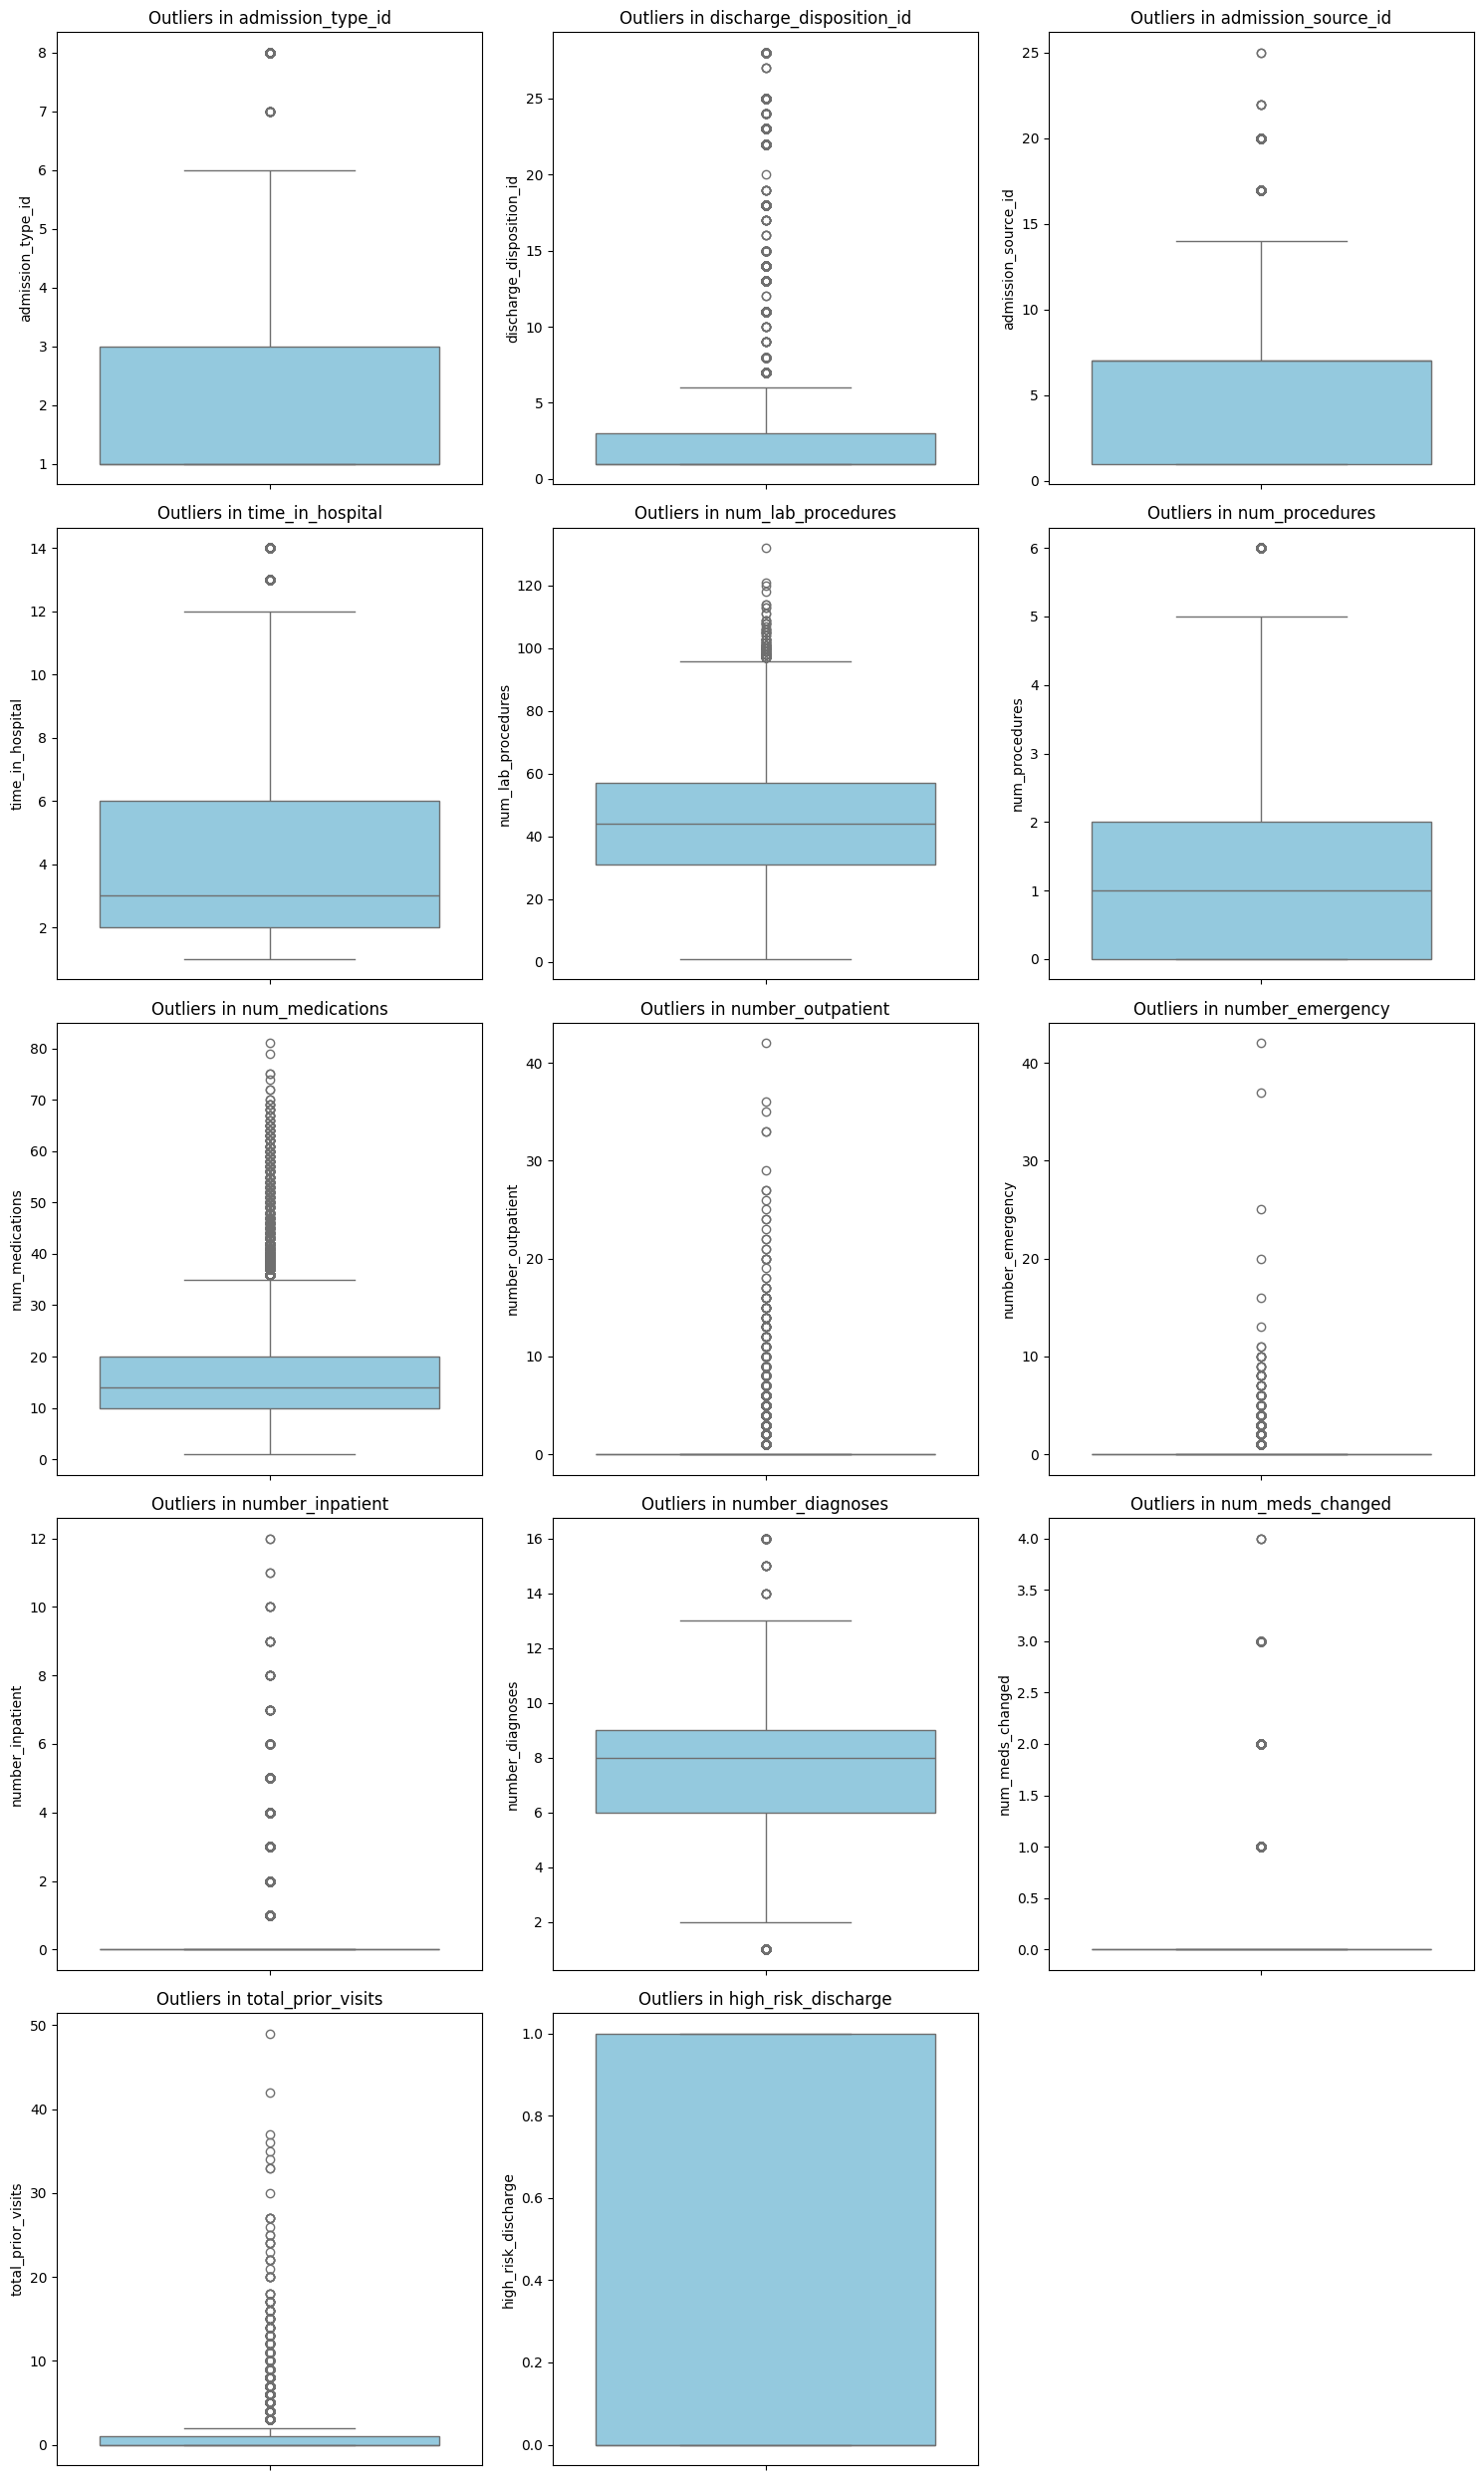

In [252]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [253]:
numeric_cols_to_fix = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]

for col in numeric_cols_to_fix:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers Capping Completed Successfully.")

Outliers Capping Completed Successfully.


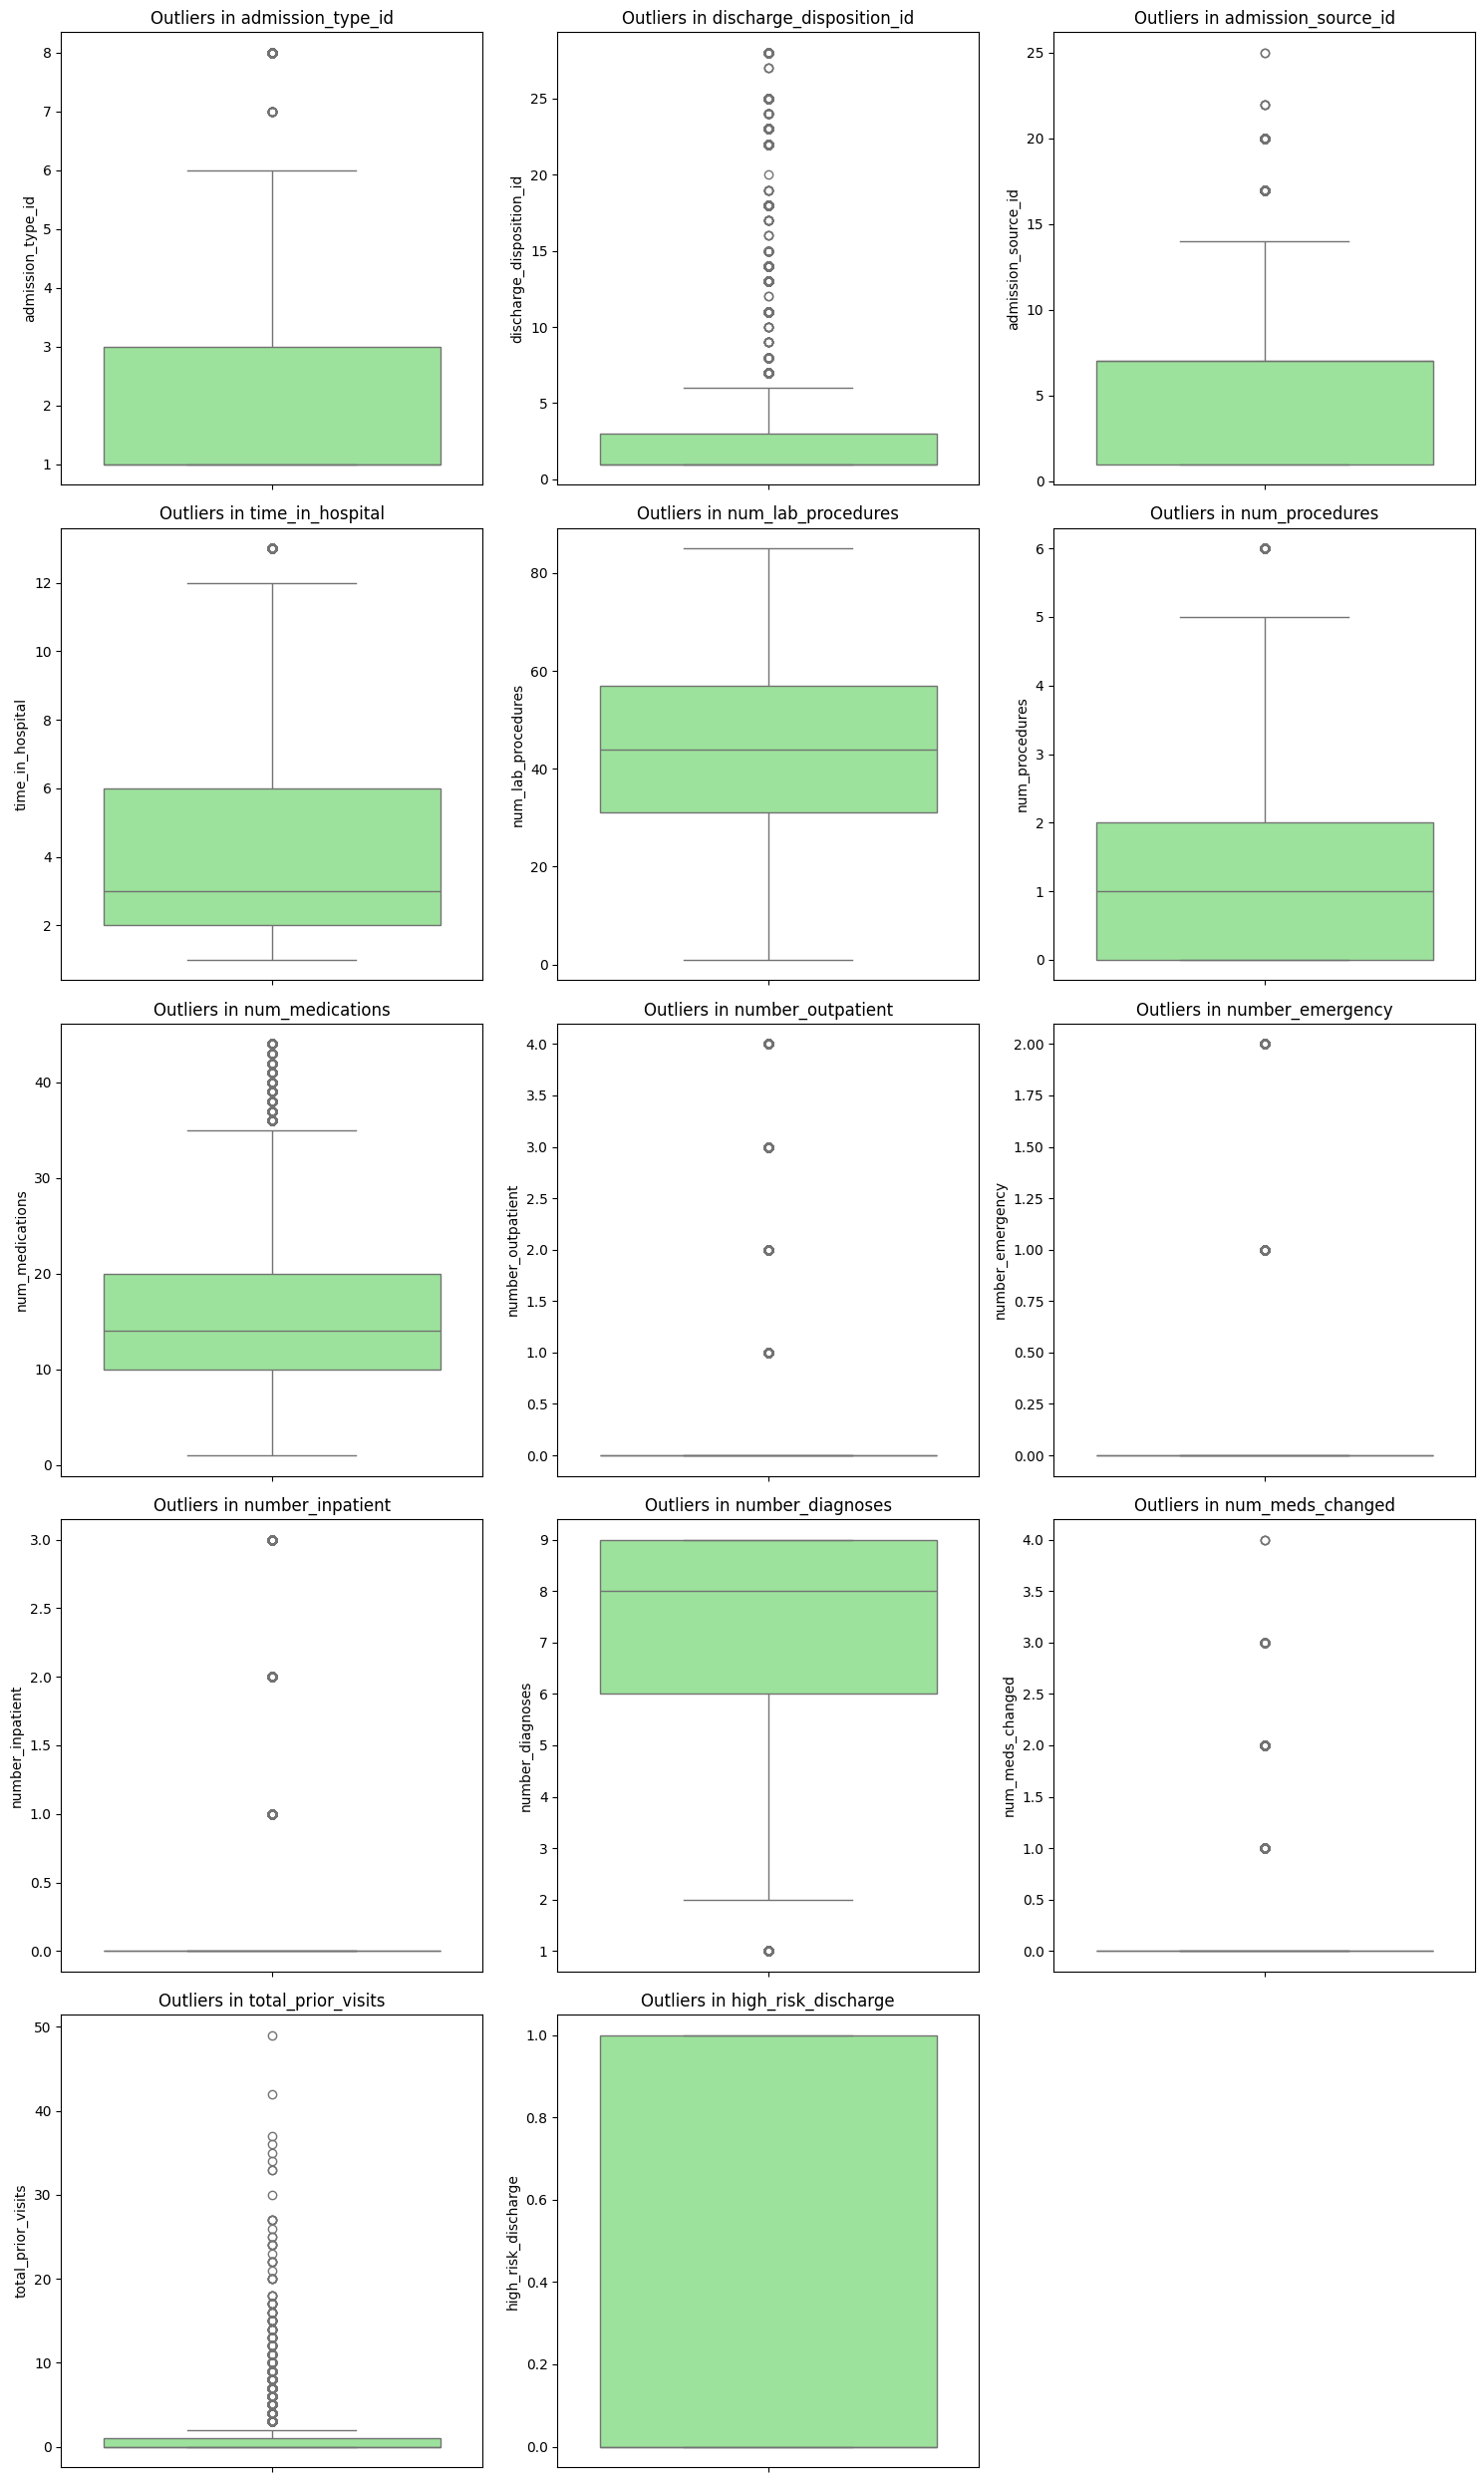

In [254]:
numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 3
rows = (n // cols) + (1 if n % cols > 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# ⚠️ Outliers Handling (Capping Method)

Outliers are extreme values that deviate significantly from the rest of the data and may affect the performance of machine learning models. In this project, instead of removing outliers, a **capping (Winsorization)** approach was used to reduce their impact while preserving the dataset size and information.

---

# 📌 Outliers Treatment Approach

## 🔹 Method Used: Capping at 99th Percentile

For each selected numerical feature, values above the 99th percentile were replaced with the 99th percentile value itself. This ensures that extreme values do not distort the overall distribution.

---

## 🔢 Features Applied

- time_in_hospital  
- num_lab_procedures  
- num_procedures  
- num_medications  
- number_outpatient  
- number_emergency  
- number_inpatient  
- number_diagnoses  

---

## 🧠 Process Explanation

- The 99th percentile (upper limit) was calculated for each feature  
- Values greater than this limit were capped  
- numpy `where` function was used for efficient replacement  

---

## 📊 Result

- Extreme values were controlled  
- Data distribution became more stable  
- No rows were removed from the dataset  
- Dataset remained intact for modeling  

---

## 🚀 Final Outcome

The dataset is now:
- Cleaned  
- Stable  
- Less affected by extreme values  
- Ready for machine learning models

# 📊 Exploratory Data Analysis (EDA):

# 📊 Univariate Analysis

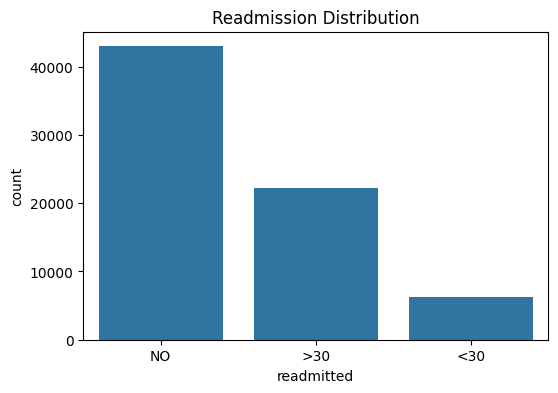

In [255]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

## 📊 Readmission Distribution Analysis

The distribution of the **Readmitted** variable shows the frequency of patient returns as follows:

* **NO**: This is the most frequent category, with over 40,000 instances.
* **>30**: This category includes approximately 22,000 cases of patients returning after 30 days.
* **<30**: This represents the smallest group, with fewer than 10,000 cases.

---
> **Note:** The dataset shows a significant class imbalance, with the majority of patients not being readmitted.

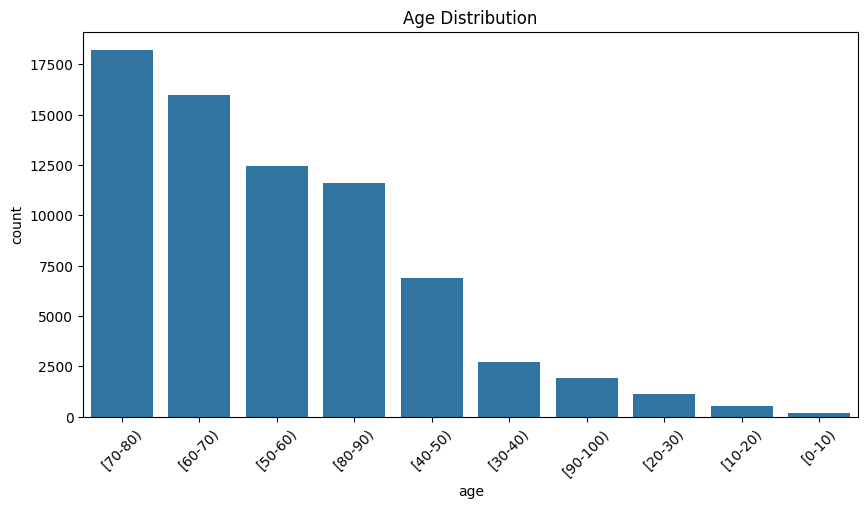

In [256]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', data=df, order=df['age'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

## 📊 Age Distribution Analysis

The age distribution in the dataset follows a downward trend toward younger age groups

* **Dominant Groups:** The majority of patients fall within the older age brackets, specifically the **[70-80)** and **[60-70)** ranges.
* **Middle Groups:** There is a significant presence of patients in the **[50-60)** and **[80-90)** categories.
* **Younger Groups:** The frequency decreases sharply for patients under the age of 50, with the **[0-10)** and **[10-20)** groups representing the smallest portion of the data.

---
> **Note:** The data is heavily skewed toward elderly patients, which is a common characteristic in diabetes-related hospital datasets.

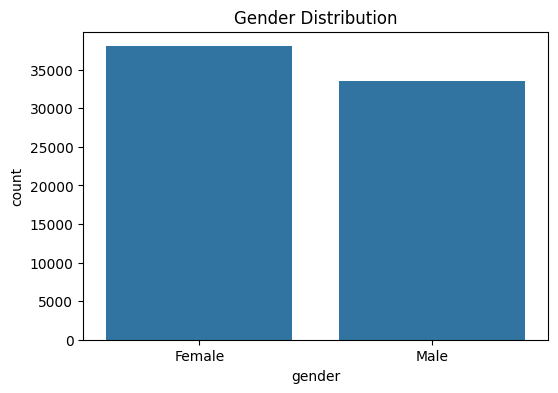

In [257]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

## 📊 Gender Distribution Analysis

The gender distribution within the dataset shows the following:

* **Female:** Represents the larger portion of the dataset, with a count exceeding 35,000.
* **Male:** Represents the secondary group, with a count of approximately 33,000.

---
> **Note:** The dataset maintains a relatively balanced distribution between both genders, with a slight majority of female patients recorded.

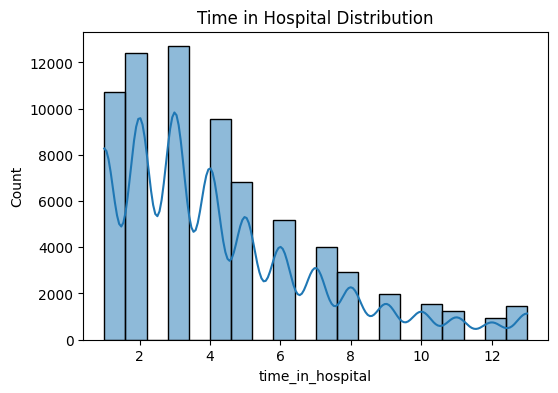

In [258]:
plt.figure(figsize=(6,4))
sns.histplot(df['time_in_hospital'], bins=20, kde=True)
plt.title("Time in Hospital Distribution")
plt.show()

## 📊 Time in Hospital Distribution Analysis

The distribution for the **time_in_hospital** variable demonstrates the following:

* **Peak Frequency:** Most patients spend between **2 to 3 days** in the hospital, which represents the highest volume of cases.
* **Short to Moderate Stays:** A significant portion of the population remains hospitalized for **1 to 5 days**.
* **Long-Term Stays:** The frequency decreases steadily as the duration increases, with very few patients staying longer than **10 days**.

---
> **Note:** The data is right-skewed, indicating that while short-term stays are the norm, there is a "long tail" of patients requiring extended hospitalization.

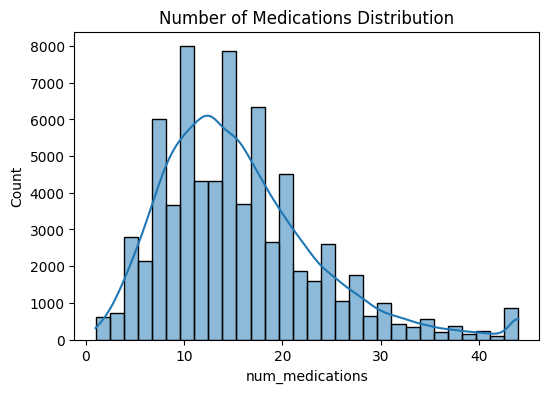

In [259]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_medications'], bins=30, kde=True)
plt.title("Number of Medications Distribution")
plt.show()

## 📊 Number of Medications Distribution Analysis

The distribution of the **num_medications** variable highlights the following patterns:

* **Peak Usage:** Most patients are prescribed between **10 to 20 medications**, with the highest frequency clustering around the 12-15 range.
* **Common Range:** A large majority of the patient population falls within the **8 to 25 medications** bracket.
* **Outliers and Extremes:** The frequency tapers off significantly beyond 30 medications, though there is a small "tail" extending up to 40+, representing more complex clinical cases.

---
> **Note:** The distribution is slightly right-skewed, indicating that while most patients take a moderate amount of medication, a subset of the population requires a significantly higher number of prescriptions.

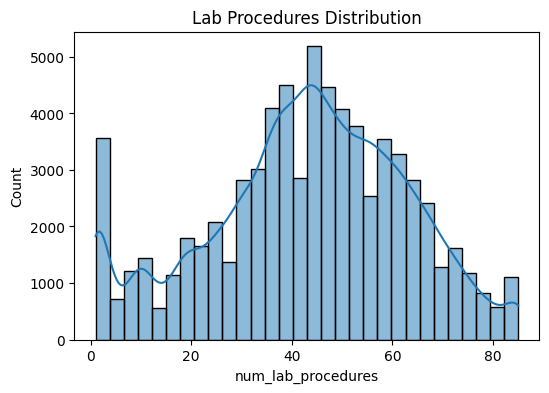

In [260]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_lab_procedures'], bins=30, kde=True)
plt.title("Lab Procedures Distribution")
plt.show()

## 📊 Lab Procedures Distribution Analysis

The distribution of the **num_lab_procedures** variable shows a multi-modal pattern with the following characteristics:

* **Peak Activity**: The highest concentration of patients undergoes between **40 to 50 lab procedures** during their stay.
* **Broad Distribution**: There is a significant spread across the data, with a large number of patients falling within the **30 to 70 procedures** range.
* **Initial Spike**: A notable secondary peak occurs at the very low end of the scale (near 0-5 procedures), representing patients with minimal laboratory testing.

---
> **Note**: The distribution is approximately normal around the central peak but exhibits high variance, indicating a wide diversity in the intensity of diagnostic monitoring among patients.

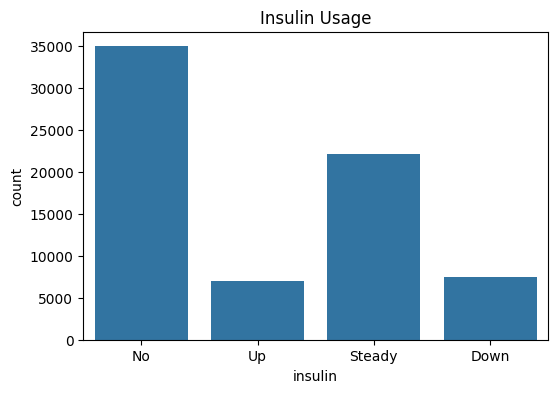

In [261]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', data=df)
plt.title("Insulin Usage")
plt.show()

## 📊 Insulin Usage Distribution Analysis

The categorical distribution for **Insulin** usage reveals the following patient trends:

* **No Insulin:** This is the most prevalent category, with approximately **35,000 cases**, indicating a large portion of patients were not prescribed insulin during their stay.
* **Steady:** The second most common category, with over **20,000 cases**, representing patients whose insulin dosage remained constant.
* **Down & Up:** These categories represent the minority, with **Down** (dosage reduction) appearing more frequently than **Up** (dosage increase), which accounts for the fewest cases in the dataset.

---
> **Note:** The high frequency of the "No" and "Steady" categories suggests that for a significant majority of the recorded encounters, insulin treatment was either not required or did not necessitate active dosage adjustments.

# 📊 Bivariate Analysis

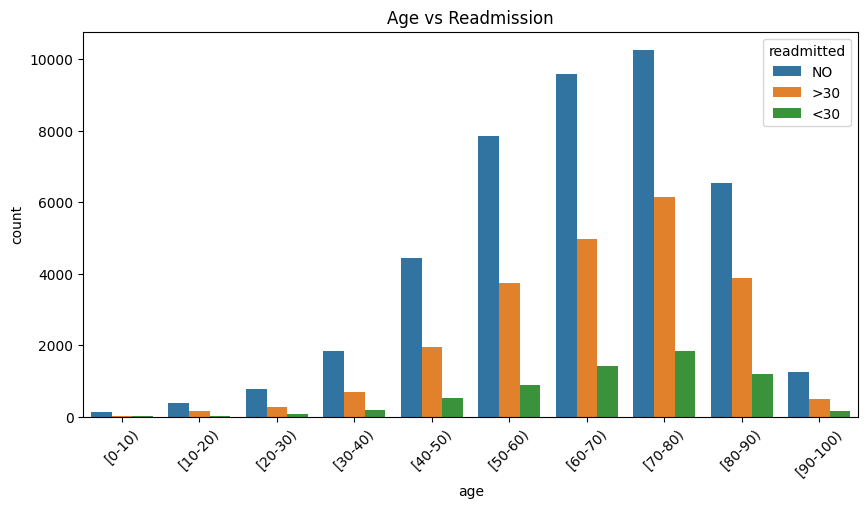

In [262]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Readmission")
plt.show()

## 📊 Age vs Readmission Analysis

The relationship between **Age** and **Readmission** status reveals several key insights into patient outcomes:

* **Correlation with Age:** Readmission counts (both **<30** and **>30**) increase significantly as patients get older, peaking in the **[70-80)** and **[60-70)** age brackets.
* **Dominant Class:** In every age group, the **NO** readmission category remains the most frequent, though the gap narrows in elderly populations.
* **High-Risk Groups:** The **[70-80)** age group shows the highest absolute volume of early readmissions (**<30** days), highlighting a critical demographic for hospital monitoring.
* **Younger Demographics:** Patients under the age of 40 have very low rates of readmission, consistent with the overall lower frequency of diabetes-related encounters in these age groups.

---
> **Note:** The trend suggests that age is a strong indicator of readmission risk, with elderly patients being significantly more likely to return to the hospital within or after 30 days.

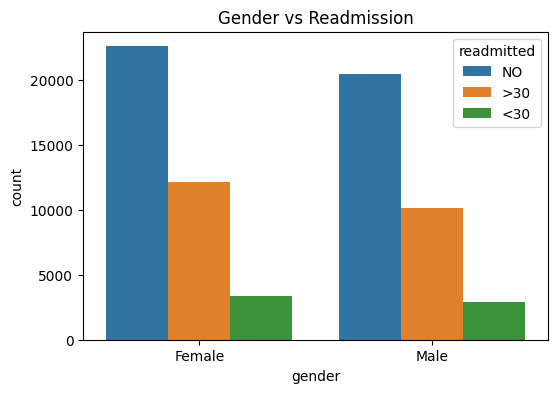

In [263]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title("Gender vs Readmission")
plt.show()

## 📊 Gender vs Readmission Analysis

The comparative analysis between **Gender** and **Readmission** status shows the following trends:

* **Readmission Consistency:** The distribution of readmission categories (**NO**, **>30**, and **<30**) appears proportionally similar for both genders.
* **Volume by Gender:** Female patients show a slightly higher total volume in all readmission categories compared to male patients.
* **Majority Class:** For both genders, the **NO** readmission category is significantly higher than the others, exceeding 20,000 for females and reaching approximately 20,000 for males.
* **Early Readmission (<30):** The frequency of early readmissions (within 30 days) is the lowest category for both males and females, remaining under 5,000 cases each.

---
> **Note:** While female patients have a higher overall count in the dataset, the likelihood of readmission does not show a significant disparity between genders.

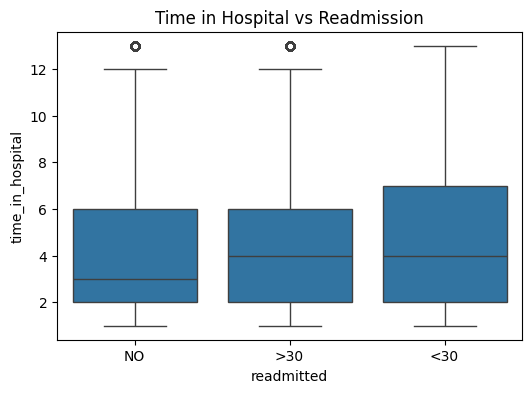

In [264]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

## 📊 Time in Hospital vs Readmission Analysis

The comparative analysis between the duration of stay (**time_in_hospital**) and **Readmission** status reveals the following insights:

* **Median Stay:** Patients who are readmitted within 30 days (**<30**) tend to have a slightly higher median time in the hospital compared to those who are not readmitted or return after 30 days.
* **Data Spread:** The interquartile range (IQR) for the **<30** group is larger, indicating more variability in the length of stay for high-risk patients.
* **Consistency:** The distributions for the **NO** and **>30** categories are very similar, with a median stay of approximately 3 to 4 days.
* **Outliers:** Both the **NO** and **>30** categories exhibit extreme outliers where hospital stays extended to 13-14 days.

---
> **Note:** The trend suggests that a longer initial hospital stay is slightly more common among patients who experience early readmission.

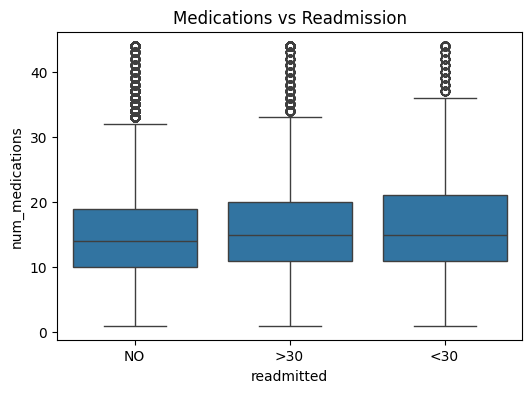

In [265]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.title("Medications vs Readmission")
plt.show()

## 📊 Medications vs Readmission Analysis

The comparative analysis between the number of medications (**num_medications**) and **Readmission** status reveals the following insights:

* **Median Medications:** Patients who are readmitted, whether before or after 30 days (**<30** or **>30**), tend to have a slightly higher median number of medications compared to those who are not readmitted.
* **Data Variability:** The **<30** group shows a slightly higher interquartile range (IQR), suggesting more variation in medication counts for patients who return to the hospital quickly.
* **Outliers:** All three categories exhibit a significant number of outliers, with some patients being prescribed over 40 medications.
* **General Trend:** There is a noticeable upward shift in medication volume for readmitted patients, with the median for the **<30** category being the highest among the three groups.

---
> **Note:** The trend suggests that a higher volume of medications is associated with an increased likelihood of hospital readmission.

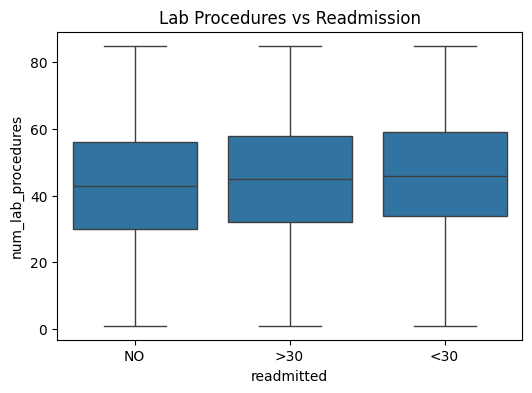

In [266]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='num_lab_procedures', data=df)
plt.title("Lab Procedures vs Readmission")
plt.show()

## 📊 Lab Procedures vs Readmission Analysis

The relationship between the number of lab procedures (**num_lab_procedures**) and **Readmission** status shows the following trends:

* **Median Lab Procedures:** Patients who were readmitted (**<30** and **>30**) exhibit a slightly higher median number of lab procedures compared to those in the **NO** category.
* **Distribution Spread:** The interquartile range (IQR) is relatively consistent across all three groups, though it sits slightly higher for readmitted patients.
* **Consistency:** The overall range of lab procedures remains broad for all categories, with counts extending from near 0 to over 80 procedures.
* **High-Risk Indicator:** The median for the **<30** group is the highest among the three, suggesting a slight correlation between more intensive diagnostic testing and early readmission.

---
> **Note:** The trend indicates that patients requiring a higher volume of laboratory procedures are slightly more likely to be readmitted to the hospital.

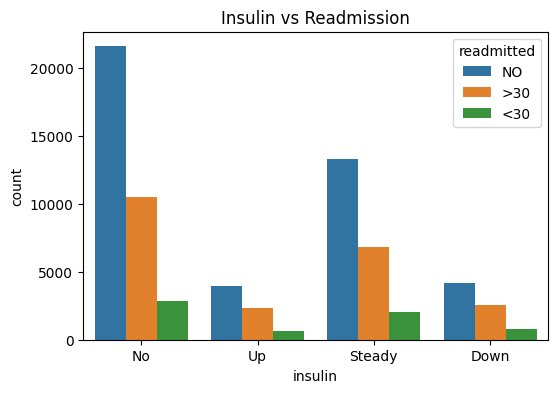

In [267]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title("Insulin vs Readmission")
plt.show()

## 📊 Insulin vs Readmission Analysis

The relationship between **Insulin** dosage changes and **Readmission** status shows the following trends:

* **Highest Volume:** The "No" insulin category has the highest total count of patients, with the majority not being readmitted (**NO**).
* **Dosage Stability:** Patients on a **Steady** insulin dose represent the second largest group, showing a similar proportion of readmissions compared to other categories.
* **Dosage Adjustments:** Patients with **Up** or **Down** dosage changes represent smaller portions of the dataset, yet they follow the same general pattern where non-readmission is the most frequent outcome.
* **Early Readmission (<30):** The frequency of early readmissions remains the lowest across all insulin categories, appearing most notably in the "No" and "Steady" groups due to their larger overall sample size.

---
> **Note:** Regardless of the insulin treatment status, the distribution of readmission categories remains relatively consistent across the groups.

# 📊 Multivariate Analysis

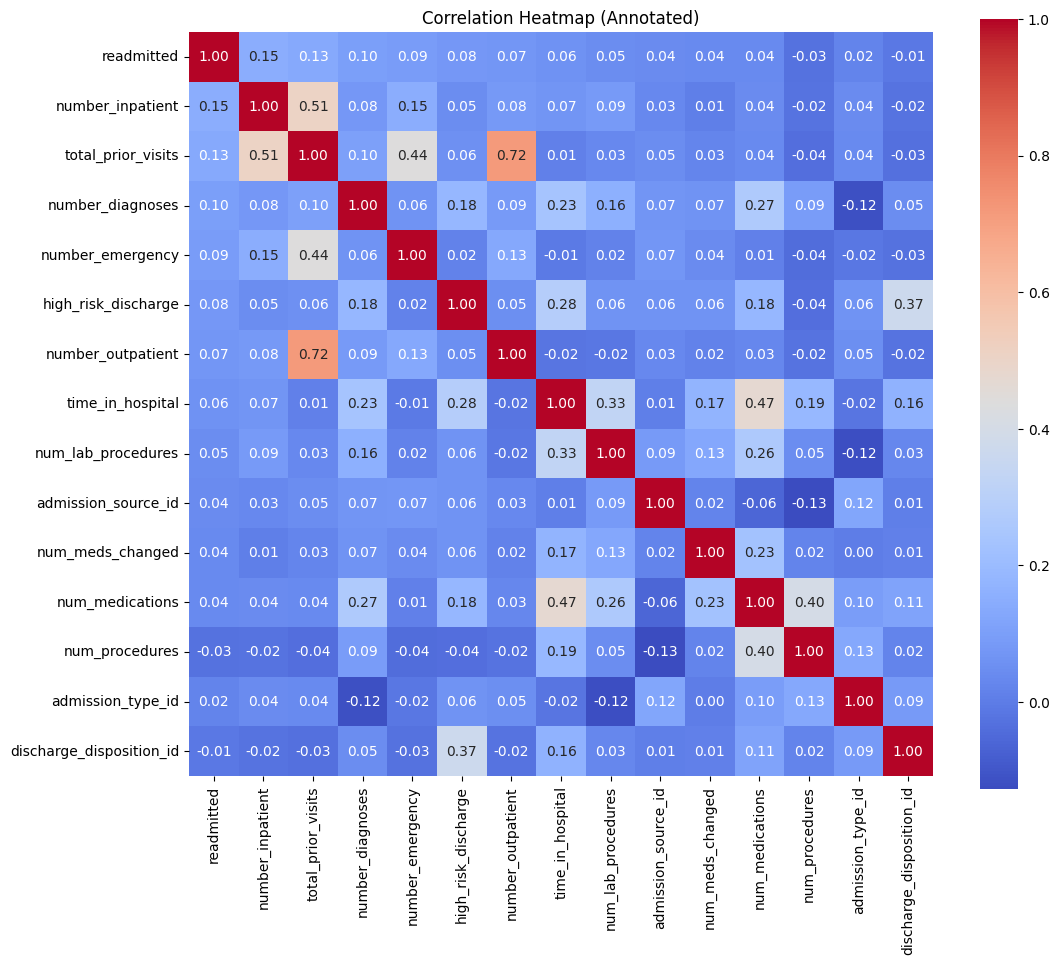

In [268]:
plt.figure(figsize=(12, 10))
# Create a temporary copy to map readmitted and show top correlations
corr_df = df.copy()
if 'readmitted' in corr_df.columns and corr_df['readmitted'].dtype == 'object':
    corr_df['readmitted'] = corr_df['readmitted'].map({'NO': 0, '<30': 1, '>30': 1})

# Filter for top features to keep the numbers readable
correlations = corr_df.corr(numeric_only=True).abs()
if 'readmitted' in correlations.columns:
    top_features = correlations['readmitted'].sort_values(ascending=False).head(15).index
    display_df = corr_df[top_features].corr()
else:
    display_df = corr_df.corr(numeric_only=True)

sns.heatmap(display_df, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Correlation Heatmap (Annotated)")
plt.show()

## 📊 Correlation Heatmap Analysis

The annotated correlation heatmap provides a quantitative overview of the relationships between different variables in the dataset:

* **Target Correlation:** The variable **readmitted** shows its strongest positive correlations with **number_inpatient** (0.15) and **total_prior_visits** (0.13), suggesting these are key predictors for hospital return.
* **Feature Interdependence:** A strong positive correlation (0.72) exists between **number_outpatient** and **total_prior_visits**, indicating these features provide similar information regarding patient history.
* **Clinical Indicators:** **Number_inpatient** and **total_prior_visits** are also notably correlated (0.51), showing that patients with high previous visits tend to have more inpatient stays.
* **Medication & Diagnostics:** There is a moderate correlation (0.47) between **time_in_hospital** and **num_medications**, as longer stays naturally involve more intensive treatment.
* **Weak Correlations:** Many administrative variables, such as **admission_type_id** and **discharge_disposition_id**, show near-zero correlation with readmission, indicating they have little linear impact on the target.

---
> **Note:** The heatmap identifies multicollinearity between certain features (like outpatient visits and prior visits), which is an important consideration for optimizing the **Logistic Regression** model.

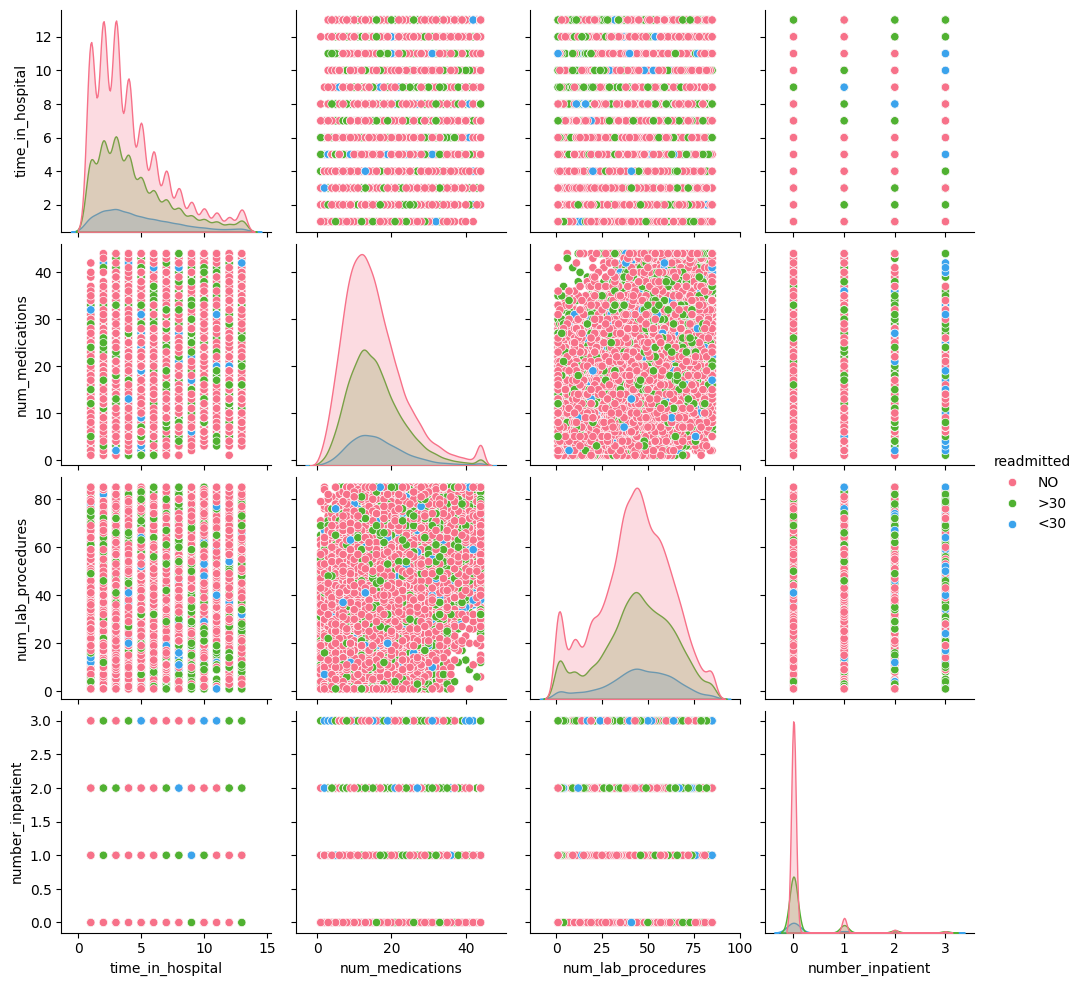

In [269]:
plot_df = df[['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient', 'readmitted']].copy()
plot_df['readmitted'] = plot_df['readmitted'].astype(str)

sns.pairplot(plot_df, hue='readmitted', palette='husl', diag_kind='kde')
plt.show()

## 📊 Pairplot Multivariate Analysis

The pairplot provides a comprehensive look at the relationships between several numerical features, colored by **readmission** status:

* **Distribution Trends (Diagonal):** The KDE plots along the diagonal confirm that most variables, such as **time_in_hospital** and **num_medications**, are right-skewed. The overlap between categories suggests that no single feature perfectly separates readmitted from non-readmitted patients.
* **Feature Interactions (Scatter Plots):** The scatter plots show dense clusters, particularly between **num_medications** and **num_lab_procedures**, indicating that as the intensity of diagnostic testing increases, the number of prescribed medications tends to follow.
* **Inpatient Impact:** The **number_inpatient** variable shows discrete horizontal bands, highlighting that patients with even one or two previous inpatient stays appear frequently in the readmitted categories (**<30** and **>30**).
* **Class Overlap:** There is significant overlapping among the three readmission classes across all pairs of features, which underscores the complexity of the classification task and the need for a robust machine learning model.

---
> **Note:** The high degree of overlap seen here suggests that while these individual features are informative, the model will need to rely on their combined interactions to accurately predict readmission.

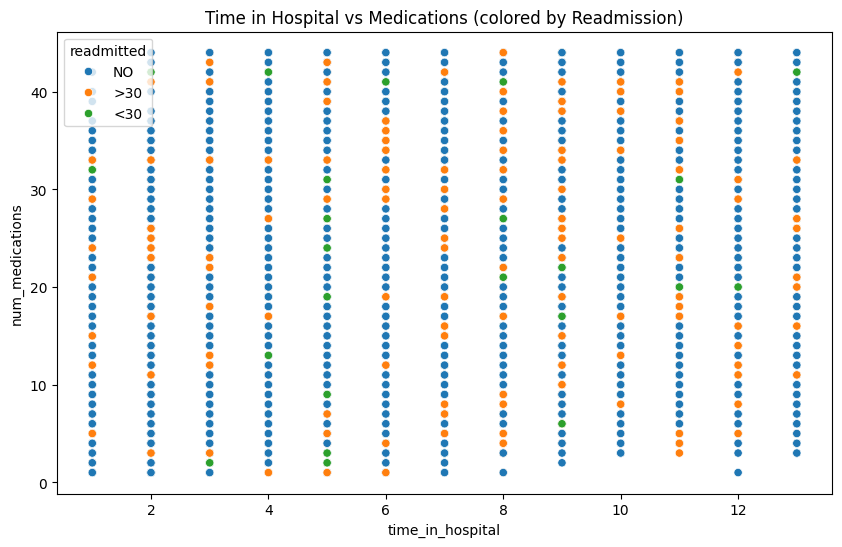

In [270]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='time_in_hospital',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.title("Time in Hospital vs Medications (colored by Readmission)")
plt.show()

## 📊 Time in Hospital vs Medications Analysis

The scatterplot exploring the relationship between **time_in_hospital** and **num_medications**, categorized by readmission status, reveals the following:

*   **Positive Correlation:** There is a visible upward trend, indicating that as the length of stay in the hospital increases, the number of medications prescribed also tends to increase.
*   **Vertical Banding:** The data points are organized in distinct vertical columns because the time spent in the hospital is recorded in discrete whole days (1 to 14 days).
*   **Density and Readmission:** While the **NO** readmission category (blue) is the most dense across all stay durations, patients readmitted within or after 30 days (**<30** and **>30**) are spread across the entire spectrum of medication counts and stay lengths.
*   **Treatment Intensity:** Patients staying longer than 10 days are almost always prescribed at least 10 medications, reflecting the higher complexity of care for long-term hospitalizations.

---
> **Note:** The overlap of colors across the plot suggests that length of stay and medication count alone are not definitive separators for readmission risk, although they are important contributing factors.

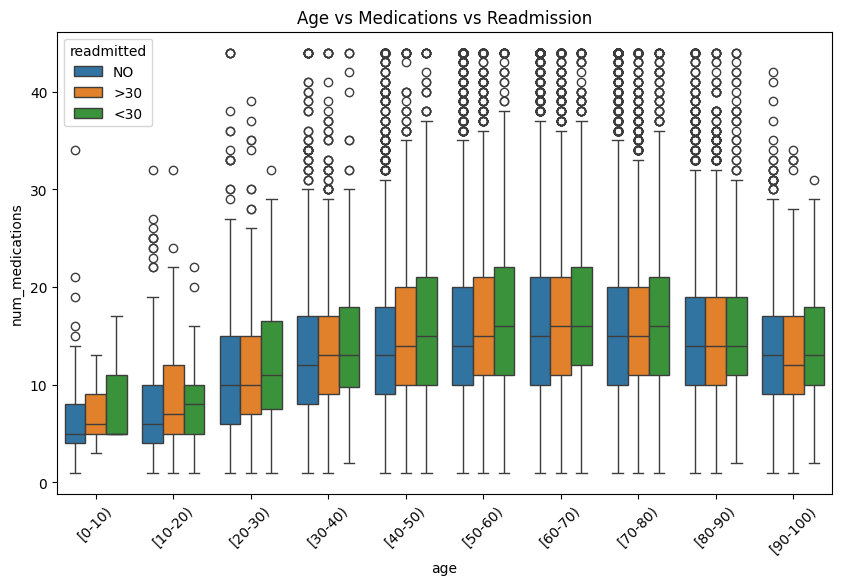

In [271]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='age',
    y='num_medications',
    hue='readmitted',
    data=df
)
plt.xticks(rotation=45)
plt.title("Age vs Medications vs Readmission")
plt.show()

## 📊 Age vs Medications vs Readmission Analysis

The boxplot analysis examining the relationship between **Age**, the number of medications (**num_medications**), and **Readmission** status highlights the following:

*   **Medication Increase with Age:** There is a clear trend where the median number of medications increases as patients get older, peaking in the **[50-60)** and **[60-70)** age brackets.
*   **Readmission Correlation:** In most age groups, patients who were readmitted (both **<30** and **>30**) tend to have a slightly higher median number of medications compared to those who were not readmitted.
*   **Presence of Outliers:** Every age group above 20 exhibits a high volume of outliers, with some patients being prescribed over 40 medications, regardless of their readmission status.
*   **Elderly Trends:** In the highest age brackets (**[80-90)** and **[90-100)**), the median number of medications begins to plateau or slightly decrease, likely due to more conservative treatment plans for very elderly patients.

---
> **Note:** The data suggests that intensive medication regimens are more common among the middle-aged and elderly populations and are associated with a slightly higher risk of early hospital return.

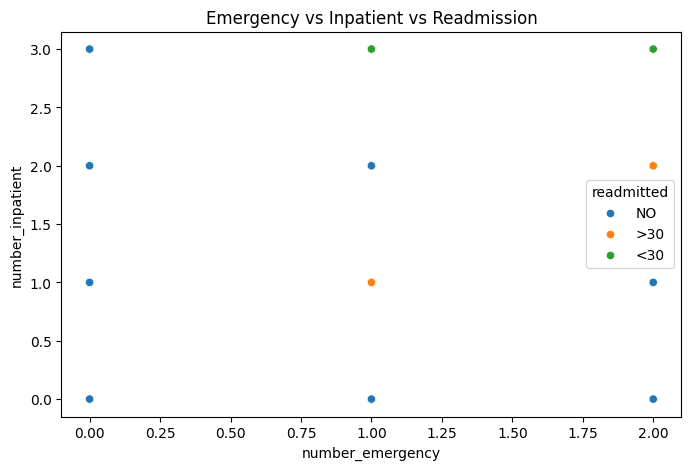

In [272]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='number_emergency',
    y='number_inpatient',
    hue='readmitted',
    data=df
)
plt.title("Emergency vs Inpatient vs Readmission")
plt.show()

## 📊 Emergency vs Inpatient vs Readmission Analysis

The scatterplot analyzing the intersection of **number_emergency**, **number_inpatient**, and **readmission** status shows the following trends:

* **Discrete Data points:** The visualization displays points in a grid-like pattern because both emergency and inpatient visits are recorded as discrete integer counts.
* **Impact of Prior Visits:** There is a noticeable presence of readmitted patients (**<30** and **>30**) as the number of emergency or inpatient visits increases, particularly for patients with at least one prior visit in either category.
* **Early Readmission Focus:** Patients with early readmission (**<30**, green points) are clearly visible in the upper-right areas of the plot, suggesting that frequent past utilization of hospital services is a strong indicator of rapid return.
* **Dominant Zero-Visit Group:** The largest concentration of non-readmitted patients (**NO**, blue points) is clustered at the (0,0) coordinate, representing patients with no prior emergency or inpatient history in the recorded period.

---
> **Note:** The trend reinforces the correlation seen in previous analyses where higher volumes of prior hospital encounters significantly increase the likelihood of future readmissions.

# 📌 Encoding

In [273]:
from sklearn.preprocessing import LabelEncoder

In [274]:
df = df.copy()

In [275]:
# Binary encode gender
le_gender = LabelEncoder()
if 'gender' in df.columns:
    df['gender'] = le_gender.fit_transform(df['gender'].astype(str))

In [276]:
# Ordinal encode medication columns (No=0, Steady=1, Up=2, Down=-1)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
med_mapping = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': -1}
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_mapping)

In [277]:
binary_mapping = {'No': 0, 'Yes': 1, 'Ch': 1}
for col in ['change', 'diabetesMed']:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

In [278]:
# One-Hot encode nominal categorical columns (no natural order)
# age is ordinal (decade brackets) so we label-encode it instead.
nominal_ohe_cols = [
    'race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult'
]
# Group rare medical_specialty values (< 1% frequency) into 'Other' to keep dimensions manageable
if 'medical_specialty' in df.columns:
    freq = df['medical_specialty'].value_counts(normalize=True)
    df['medical_specialty'] = df['medical_specialty'].where(
        df['medical_specialty'].isin(freq[freq >= 0.01].index), other='Other'
    )

df = pd.get_dummies(df,
                    columns=[c for c in nominal_ohe_cols if c in df.columns],
                    drop_first=True)

In [279]:
# LabelEncode age — ordinal decade brackets ([0-10), [10-20), ...) have a natural order
if 'age' in df.columns:
    df['age'] = LabelEncoder().fit_transform(df['age'].astype(str))

In [280]:
# Map the target variable to binary
df['readmitted'] = df['readmitted'].map({
    'NO': 0,
    '>30': 0,
    '<30': 1
})

In [281]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

print(f'Encoding complete. Final shape: {df.shape}')

Encoding complete. Final shape: (71518, 137)


# 🔄 Feature Encoding

Feature encoding is a critical preprocessing step in machine learning where categorical variables are transformed into numerical representations so that machine learning algorithms can process them effectively.

Since the diabetic healthcare dataset contained multiple categorical features with different characteristics, several encoding techniques were applied depending on the type and behavior of each feature.

---

# 📌 Encoding Process

## 1️⃣ Gender Encoding (Label Encoding)

The `gender` column was converted into numerical values using **Label Encoding**.

### 🔹 Example
- Female → `0`
- Male → `1`

This step transformed binary categorical data into a machine-readable numerical format.

---

## 2️⃣ Medication Feature Encoding (Ordinal Mapping)

Medication-related features contained categories representing dosage changes over time.

To preserve the meaning and direction of medication adjustments, an **ordinal mapping** strategy was applied.

### 💊 Medication Mapping

| Medication Status | Encoded Value |
|---|---|
| No | `0` |
| Steady | `1` |
| Up | `2` |
| Down | `-1` |

This encoding preserved the clinical significance of dosage increases and decreases.

### 📂 Medication Columns Included

- `metformin`
- `repaglinide`
- `nateglinide`
- `chlorpropamide`
- `glimepiride`
- `acetohexamide`
- `glipizide`
- `glyburide`
- `tolbutamide`
- `pioglitazone`
- `rosiglitazone`
- `acarbose`
- `miglitol`
- `troglitazone`
- `tolazamide`
- `examide`
- `citoglipton`
- `insulin`
- `glyburide-metformin`
- `glipizide-metformin`
- `glimepiride-pioglitazone`
- `metformin-rosiglitazone`
- `metformin-pioglitazone`

---

## 3️⃣ Binary Feature Encoding

Binary categorical features were encoded using numerical mapping.

### 🔹 Binary Mapping

| Original Value | Encoded Value |
|---|---|
| No | `0` |
| Yes | `1` |
| Ch | `1` |

### 📂 Applied To

- `change`
- `diabetesMed`

This conversion ensured compatibility with machine learning algorithms while preserving binary meaning.

---

## 4️⃣ Rare Category Reduction

The `medical_specialty` feature contained a large number of rare categories that could unnecessarily increase dimensionality after encoding.

To reduce complexity and improve model generalization:

- categories representing less than **1%** of the dataset frequency
were grouped into:

- `"Other"`

This helped keep the feature space manageable while preserving important information.

---

## 5️⃣ One-Hot Encoding

Nominal categorical features with multiple independent categories were transformed using **One-Hot Encoding**.

### 📂 One-Hot Encoded Features

- `race`
- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`
- `medical_specialty`
- `diag_1`
- `diag_2`
- `diag_3`
- `max_glu_serum`
- `A1Cresult`

### ✅ Why One-Hot Encoding?

One-Hot Encoding prevents machine learning models from assuming any ordinal relationship between categories.

Additionally:
- `drop_first=True` was used to reduce multicollinearity and avoid the dummy variable trap.

---

## 6️⃣ Age Encoding

The `age` column was encoded using **Label Encoding** after converting age ranges into categorical string values.

Each age category was assigned a unique numerical label.

### 🔹 Example

| Age Range | Encoded Value |
|---|---|
| [0-10) | `0` |
| [10-20) | `1` |
| ... | ... |

This allowed age groups to be represented numerically while maintaining ordering information.

---

## 7️⃣ Target Variable Encoding

The target column:

- `readmitted`

was transformed into a binary classification target.

### 🎯 Readmission Mapping

| Original Value | Encoded Value |
|---|---|
| NO | `0` |
| >30 | `0` |
| <30 | `1` |

### ✅ Interpretation
- `0` → No early readmission
- `1` → Patient readmitted within 30 days

This conversion transformed the problem into a binary classification task.

---

## 8️⃣ Boolean Conversion

All boolean columns were converted into integer format.

### 🔹 Boolean Mapping

| Boolean Value | Integer Value |
|---|---|
| True | `1` |
| False | `0` |

This ensured full numerical consistency across the dataset.

---

# ✅ Encoding Results

After completing the encoding stage:

✔️ All categorical features were successfully converted into numerical format  
✔️ High-cardinality features were optimized  
✔️ Rare categories were reduced to improve generalization  
✔️ Dataset dimensionality became more manageable  
✔️ Boolean values were standardized  
✔️ The target variable was prepared for binary classification  

---

# 🚀 Dataset Ready For

The encoded dataset became fully compatible with machine learning workflows including:

- 🤖 Machine Learning Modeling
- 📊 Feature Selection
- 📈 Data Visualization
- ⚖️ Model Evaluation
- 🔍 Hyperparameter Tuning
- 🏥 Predictive Healthcare Analytics
- 🌐 Deployment

---

## 🎯 Final Outcome

After feature encoding, the diabetic dataset became completely numerical, structured, and optimized for training accurate and reliable machine learning models for patient readmission prediction.

<div align="center">

# 🤖 Phase 2 — Machine Learning Pipeline

</div>

# 1️⃣ Dataset Health Check
Confirm the dataset is clean, fully numeric, and ready for ML.

In [282]:
# ── 1. Dataset Health Check ──────────────────────────────────────────────
print("=" * 60)
print("📋  DATASET HEALTH CHECK")
print("=" * 60)
print(f"\n🔹 Shape          : {df.shape}")
print(f"🔹 Total samples  : {df.shape[0]:,}")
print(f"🔹 Total features : {df.shape[1]}")
print(f"\n🔹 Missing values : {df.isna().sum().sum()}")
print(f"🔹 Duplicate rows : {df.duplicated().sum()}")
print("\n🔹 Data types:")
print(df.dtypes.value_counts())
print("\n🔹 Target variable (readmitted) distribution:")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(4) * 100)

📋  DATASET HEALTH CHECK

🔹 Shape          : (71518, 137)
🔹 Total samples  : 71,518
🔹 Total features : 137

🔹 Missing values : 0
🔹 Duplicate rows : 1

🔹 Data types:
int64      129
float64      8
Name: count, dtype: int64

🔹 Target variable (readmitted) distribution:
readmitted
0    65225
1     6293
Name: count, dtype: int64
readmitted
0    91.2
1     8.8
Name: proportion, dtype: float64


# 2️⃣ Feature / Target Split
#
- **X** = all feature columns (everything except `readmitted`)
- **y** = target column (`readmitted`)
#
Target classes:
| Value | Meaning |
|-------|---------|
| 0 | Not readmitted within 30 days |
| 1 | Readmitted within 30 days |

In [283]:
# ── 2. Feature / Target Split ────────────────────────────────────────────
X = df.drop(columns=['readmitted'])
y = df['readmitted']
print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"✅ Target classes  : {sorted(y.unique())}")

✅ Features shape : (71518, 136)
✅ Target shape   : (71518,)
✅ Target classes  : [np.int64(0), np.int64(1)]


# 3️⃣ Train / Test Split
#
- 80 % training, 20 % testing
- `stratify=y` ensures the class ratio is preserved in both splits
- `random_state=42` for reproducibility

In [284]:
# ── 3. Train / Test Split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ y_train : {y_train.shape}  — distribution:\n{y_train.value_counts()}")
print(f"✅ y_test  : {y_test.shape}   — distribution:\n{y_test.value_counts()}")

✅ X_train : (57214, 136)
✅ X_test  : (14304, 136)
✅ y_train : (57214,)  — distribution:
readmitted
0    52180
1     5034
Name: count, dtype: int64
✅ y_test  : (14304,)   — distribution:
readmitted
0    13045
1     1259
Name: count, dtype: int64


# 4️⃣ Feature Scaling
#
StandardScaler normalises features to mean = 0, std = 1.
- **Fit** on training data only (to avoid data leakage)
- **Transform** both train and test sets

In [285]:
# ── 4. Feature Scaling ───────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)
print("✅ Feature scaling complete.")
print(f"   Train mean ≈ {X_train_scaled.mean().mean():.6f}  |  std ≈ {X_train_scaled.std().mean():.4f}")

✅ Feature scaling complete.
   Train mean ≈ 0.000000  |  std ≈ 0.9706


# 5️⃣ Handle Class Imbalance (RandomUnderSampler)
#
**Why RandomUnderSampler?**
The dataset is heavily imbalanced — most patients are in class 0 (NO readmission).
Training on imbalanced data causes the model to become biased toward the majority class.
Using SMOTE on this large dataset creates too many synthetic samples and makes training
extremely slow. Instead, we use RandomUnderSampler to downsample the majority classes
to match the minority class, drastically reducing processing time while maintaining balance.
#
⚠️ Under-sampling is applied **only on the training set** to prevent data leakage into testing.

In [286]:
# ── 5. Handle Class Imbalance ────────────────────────────────────────────
from imblearn.under_sampling import RandomUnderSampler
print("Before UnderSampling:")
print(y_train.value_counts())
rus = RandomUnderSampler(random_state=42)
X_train_sm, y_train_sm = rus.fit_resample(X_train_scaled, y_train)
print("\nAfter UnderSampling:")
print(pd.Series(y_train_sm).value_counts())
print(f"\n✅ Training samples decreased from {len(y_train):,} → {len(y_train_sm):,}")

Before UnderSampling:
readmitted
0    52180
1     5034
Name: count, dtype: int64

After UnderSampling:
readmitted
0    5034
1    5034
Name: count, dtype: int64

✅ Training samples decreased from 57,214 → 10,068


# 6️⃣ Machine Learning Models
#
Training & evaluating **5 classifiers**:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

In [287]:
# ── 6. Model Training & Evaluation ───────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import HistGradientBoostingClassifier
# Dictionary of models
models = {
    'Logistic Regression':      LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':            DecisionTreeClassifier(random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'HistGradientBoosting':     HistGradientBoostingClassifier(
                                    max_iter=300, learning_rate=0.05,
                                    max_depth=6, random_state=42),
    'KNN':                      KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVM':                      SVC(kernel='rbf', random_state=42, probability=True),
}
# Storage for results
results = []
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train a model, predict, print metrics, and return a results dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    print("=" * 60)
    print(f"🔷  {name}")
    print("=" * 60)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n  Classification Report:\n{classification_report(y_te, y_pred, zero_division=0)}")
    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'y_pred': y_pred, 'trained': model
    }
# Train all models
for name, model in models.items():
    res = evaluate_model(name, model, X_train_sm, y_train_sm, X_test_scaled, y_test)
    results.append(res)

🔷  Logistic Regression
  Accuracy  : 0.6503
  Precision : 0.8687
  Recall    : 0.6503
  F1 Score  : 0.7258

  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.77     13045
           1       0.14      0.56      0.22      1259

    accuracy                           0.65     14304
   macro avg       0.54      0.61      0.50     14304
weighted avg       0.87      0.65      0.73     14304

🔷  Decision Tree
  Accuracy  : 0.5408
  Precision : 0.8521
  Recall    : 0.5408
  F1 Score  : 0.6374

  Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.54      0.68     13045
           1       0.10      0.54      0.17      1259

    accuracy                           0.54     14304
   macro avg       0.51      0.54      0.43     14304
weighted avg       0.85      0.54      0.64     14304

🔷  Random Forest
  Accuracy  : 0.6153
  Precision : 0.8708
  Recall    : 0.6153
  F1 S

# 7️⃣ Model Comparison

In [288]:
# ── 7. Model Comparison Table ────────────────────────────────────────────
comparison_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']]
comparison_df = comparison_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print("\n📊  MODEL COMPARISON (sorted by F1 Score):\n")
print(comparison_df.to_string(index=False))
best_row = comparison_df.iloc[0]
best_model_name = best_row['Model']
best_model_obj  = [r['trained'] for r in results if r['Model'] == best_model_name][0]
print(f"\n🏆  Best Model: {best_model_name}")
print(f"   → F1 Score = {best_row['F1 Score']:.4f}  |  Accuracy = {best_row['Accuracy']:.4f}")


📊  MODEL COMPARISON (sorted by F1 Score):

               Model  Accuracy  Precision   Recall  F1 Score
 Logistic Regression  0.650308   0.868713 0.650308  0.725814
                 SVM  0.647371   0.868863 0.647371  0.723583
HistGradientBoosting  0.629964   0.872746 0.629964  0.710139
       Random Forest  0.615282   0.870828 0.615282  0.698517
                 KNN  0.592142   0.861193 0.592142  0.680089
       Decision Tree  0.540828   0.852133 0.540828  0.637405

🏆  Best Model: Logistic Regression
   → F1 Score = 0.7258  |  Accuracy = 0.6503


# 8️⃣ Feature Importance
#
Tree-based models (Random Forest, XGBoost, Decision Tree) provide built-in
feature importance scores. We plot the **top 15 features** from the best
tree-based model to understand which medical factors most influence readmission.

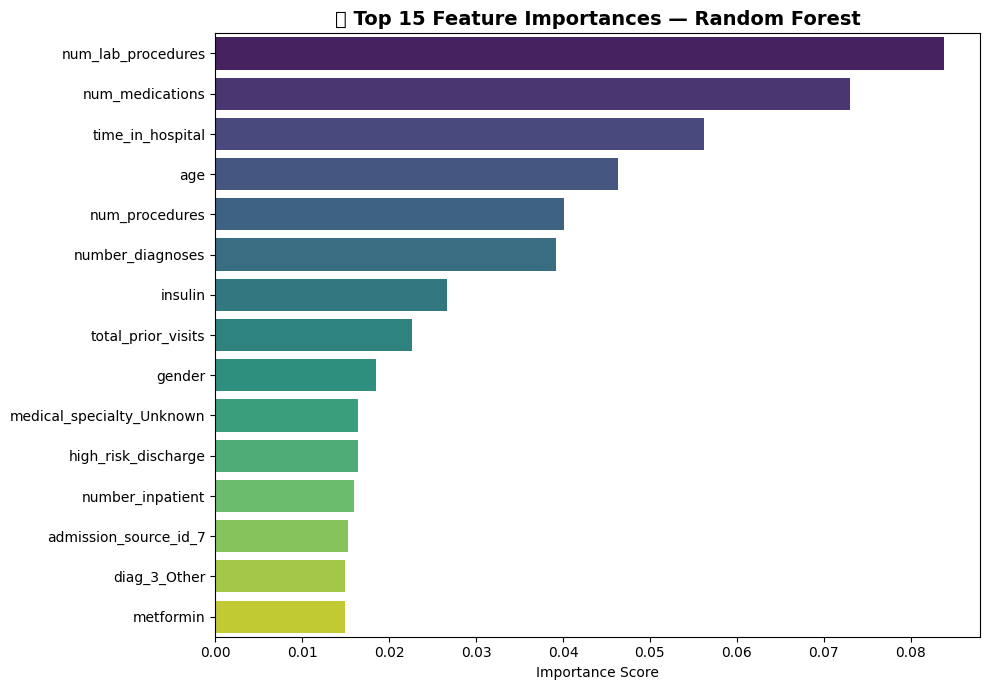


📌 Top 5 most influential features:
   • num_lab_procedures              →  0.0838
   • num_medications                 →  0.0731
   • time_in_hospital                →  0.0562
   • age                             →  0.0463
   • num_procedures                  →  0.0401


In [289]:
# ── 8. Feature Importance ────────────────────────────────────────────────
# Pick the best tree-based model for importance
tree_models = {r['Model']: r['trained'] for r in results
               if r['Model'] in ['Random Forest', 'Decision Tree']}
# Prefer Random Forest, then Decision Tree
for pref in ['Random Forest', 'Decision Tree']:
    if pref in tree_models:
        fi_model_name = pref
        fi_model = tree_models[pref]
        break
importances = fi_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title(f'🔬 Top 15 Feature Importances — {fi_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Top 5 most influential features:")
for i, row in feat_imp.head(5).iterrows():
    print(f"   • {row['Feature']:30s}  →  {row['Importance']:.4f}")

# 9️⃣ Hyperparameter Tuning
#
Using **RandomizedSearchCV** (faster than GridSearchCV on large datasets)
to find the best hyperparameters for **Random Forest**.

In [290]:
# ── 9. Hyperparameter Tuning ─────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

# ── Random Forest tuning ──
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
print("Tuning Random Forest ...")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=15, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_sm, y_train_sm)
print(f"   Best params : {rf_search.best_params_}")
print(f"   Best CV F1  : {rf_search.best_score_:.4f}")

# ── HistGradientBoosting tuning ──
hgb_param_grid = {
    'max_iter':      [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth':     [4, 6, 8, None],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
}
print("\nTuning HistGradientBoosting ...")
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    hgb_param_grid,
    n_iter=15, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=0
)
hgb_search.fit(X_train_sm, y_train_sm)
print(f"   Best params : {hgb_search.best_params_}")
print(f"   Best CV F1  : {hgb_search.best_score_:.4f}")

# ── Compare all tuned candidates ──
rf_tuned_pred  = rf_search.best_estimator_.predict(X_test_scaled)
hgb_tuned_pred = hgb_search.best_estimator_.predict(X_test_scaled)
rf_orig  = [r for r in results if r['Model'] == 'Random Forest'][0]
hgb_orig = [r for r in results if r['Model'] == 'HistGradientBoosting'][0]

print("\nTuned vs Untuned Performance (F1 weighted):")
print(f"   Random Forest      — Before: {rf_orig['F1 Score']:.4f}  |  After: {f1_score(y_test, rf_tuned_pred, average='weighted'):.4f}")
print(f"   HistGradBoosting   — Before: {hgb_orig['F1 Score']:.4f}  |  After: {f1_score(y_test, hgb_tuned_pred, average='weighted'):.4f}")

# Automatically pick the best tuned model
tuned_candidates = {
    'Random Forest (Tuned)':         (rf_search.best_estimator_,  rf_tuned_pred),
    'HistGradientBoosting (Tuned)':  (hgb_search.best_estimator_, hgb_tuned_pred),
}
best_tuned_name = max(
    tuned_candidates,
    key=lambda k: f1_score(y_test, tuned_candidates[k][1], average='weighted')
)
best_final_model = tuned_candidates[best_tuned_name][0]
best_final_pred  = tuned_candidates[best_tuned_name][1]
print(f"\nBest tuned model: {best_tuned_name}")

Tuning Random Forest ...
   Best params : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
   Best CV F1  : 0.6040

Tuning HistGradientBoosting ...
   Best params : {'min_samples_leaf': 10, 'max_iter': 500, 'max_depth': 8, 'learning_rate': 0.03, 'l2_regularization': 0.1}
   Best CV F1  : 0.5972

Tuned vs Untuned Performance (F1 weighted):
   Random Forest      — Before: 0.6985  |  After: 0.7036
   HistGradBoosting   — Before: 0.7101  |  After: 0.7004

Best tuned model: Random Forest (Tuned)


# 🔟 Cross Validation (Stratified K-Fold)
#
Stratified K-Fold ensures each fold preserves the class distribution.
We use **5-fold** CV to measure model stability.

In [291]:
# ── 10. Cross Validation ─────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_final_model, X_train_sm, y_train_sm,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"📊 Stratified 5-Fold Cross Validation — {best_tuned_name}")
print(f"   Fold scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Mean F1     : {cv_scores.mean():.4f}")
print(f"   Std Dev     : {cv_scores.std():.4f}")
if cv_scores.std() < 0.02:
    print("   ✅ Model is highly stable (low variance across folds).")
elif cv_scores.std() < 0.05:
    print("   ⚠️ Model is moderately stable.")
else:
    print("   ❌ High variance — consider more regularisation or different model.")

📊 Stratified 5-Fold Cross Validation — Random Forest (Tuned)
   Fold scores : ['0.6013', '0.6151', '0.6012', '0.5939', '0.6132']
   Mean F1     : 0.6049
   Std Dev     : 0.0080
   ✅ Model is highly stable (low variance across folds).


# 1️⃣1️⃣ ROC Curve & AUC (Binary Classification)
#
For binary classification we compute the ROC curve and AUC.

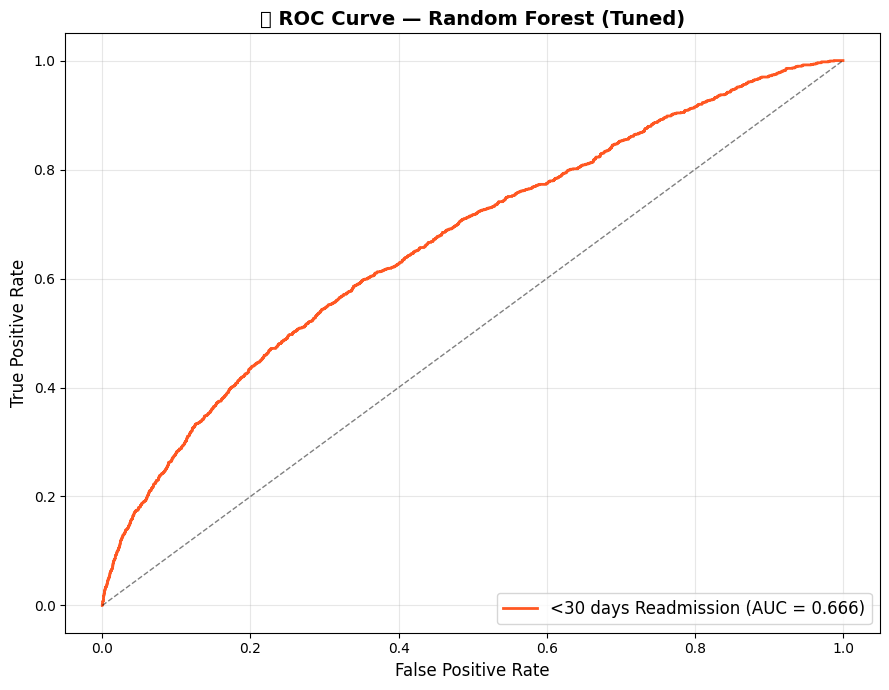


📊 AUC: 0.6664


In [292]:
# ── 11. ROC Curve & AUC ──────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

if hasattr(best_final_model, 'predict_proba'):
    y_prob = best_final_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_prob = best_final_model.decision_function(X_test_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#FF5722', lw=2,
        label=f'<30 days Readmission (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'📈 ROC Curve — {best_tuned_name}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 AUC: {roc_auc:.4f}")

# 1️⃣2️⃣ Save Final Model & Scaler

In [293]:
# ── 12. Save Model & Scaler ──────────────────────────────────────────────
import joblib
joblib.dump(best_final_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model saved  → diabetes_model.pkl")
print("✅ Scaler saved → scaler.pkl")

✅ Model saved  → diabetes_model.pkl
✅ Scaler saved → scaler.pkl


# 1️⃣3️⃣ Deployment — Prediction Function
#
A ready-to-use function that accepts raw patient data,
scales it, and returns a human-readable readmission prediction.

In [294]:
# ── 13. Prediction Function ──────────────────────────────────────────────
def predict_readmission(input_data, model_path='diabetes_model.pkl', scaler_path='scaler.pkl'):
    """
    Predict hospital readmission for a diabetic patient.
    Parameters
    ----------
    input_data : dict or list
        A dictionary (single patient) or list of values matching the
        training feature order.
    model_path : str
        Path to the saved model .pkl file.
    scaler_path : str
        Path to the saved scaler .pkl file.
    Returns
    -------
    str
        Human-readable prediction result.
    """
    loaded_model  = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = loaded_scaler.transform(input_df)
    prediction   = loaded_model.predict(input_scaled)[0]
    labels = {
        0: '✅ Not Readmitted within 30 days',
        1: '⚠️ Readmitted within 30 days',
    }
    result = labels.get(prediction, f'Unknown class ({prediction})')
    print(f"🩺 Prediction: {result}")
    return result
# Quick smoke test with the first test sample
sample = X_test.iloc[0].to_dict()
print("Sample patient features (first test row):")
predict_readmission(sample)

Sample patient features (first test row):
🩺 Prediction: ⚠️ Readmitted within 30 days


'⚠️ Readmitted within 30 days'

# 1️⃣4️⃣ Professional Visualisations

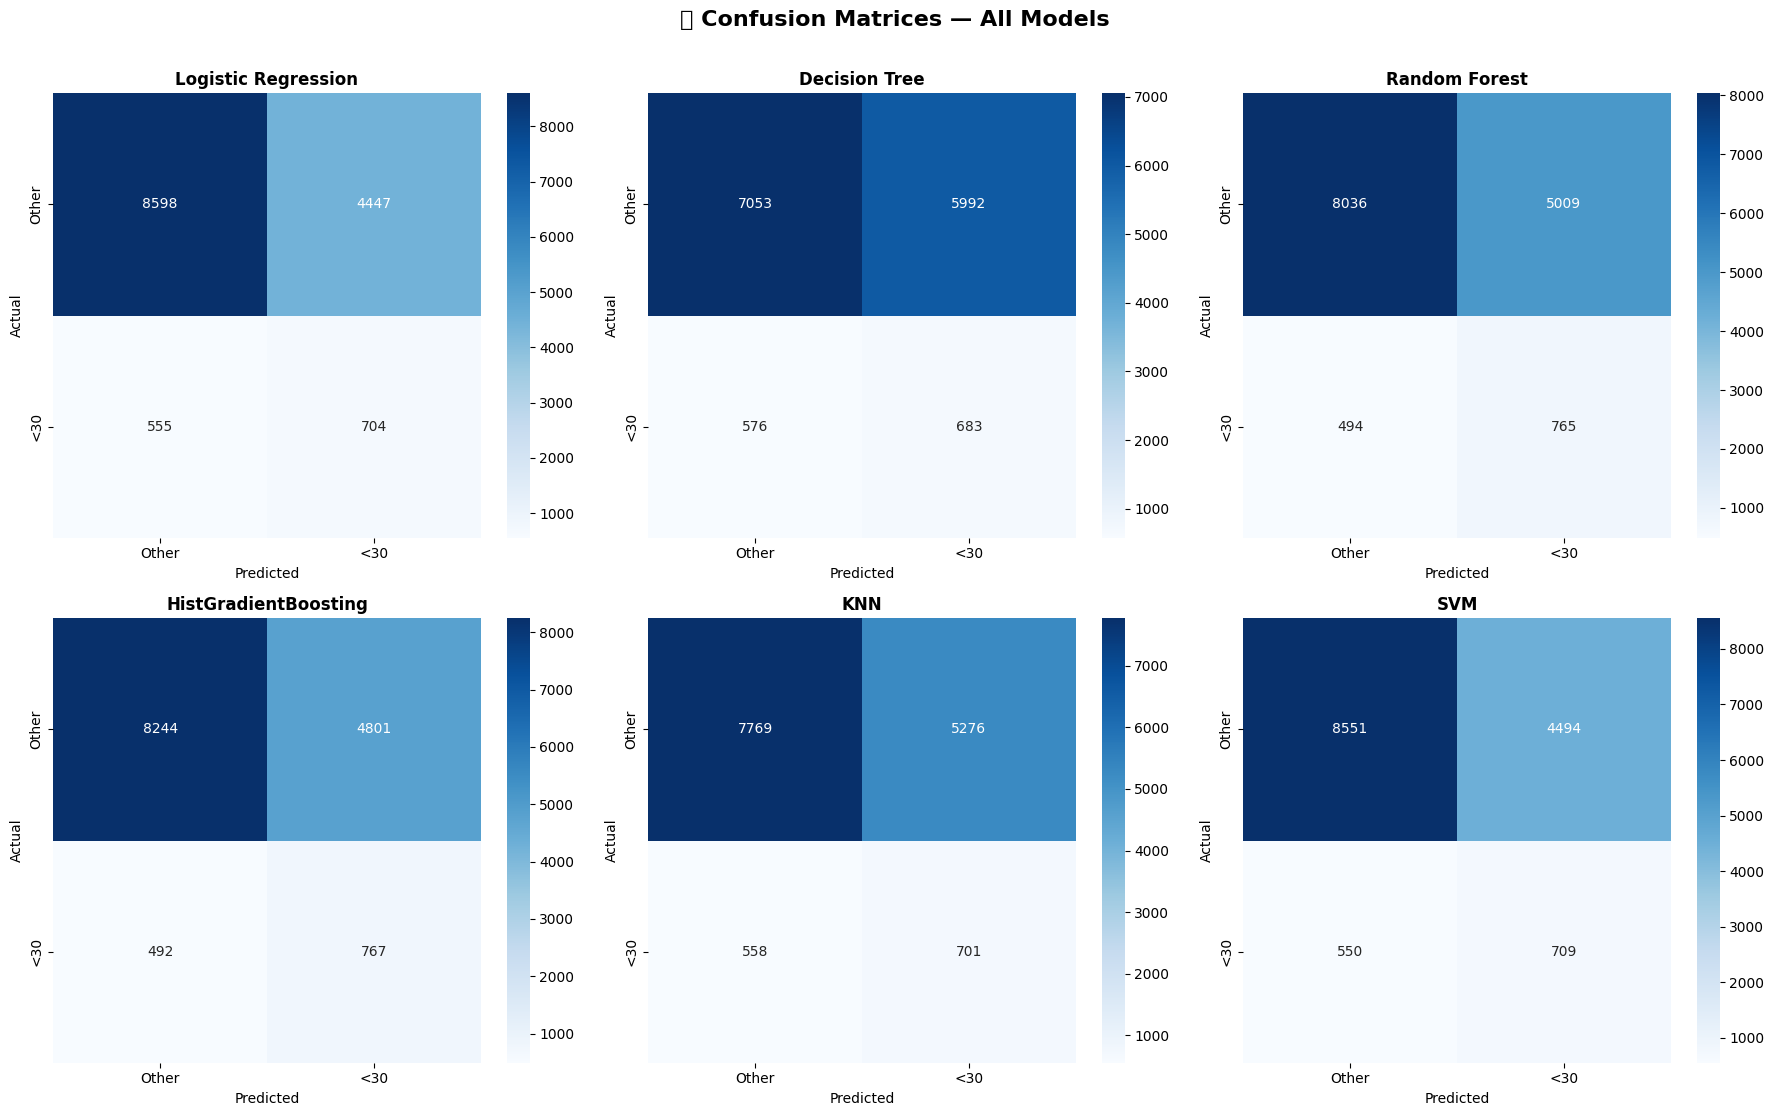

In [295]:
# ── 14-a. Confusion Matrices for All Models ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for idx, res in enumerate(results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Other', '<30'],
                yticklabels=['Other', '<30'])
    axes[idx].set_title(res['Model'], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
fig.suptitle('🔍 Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

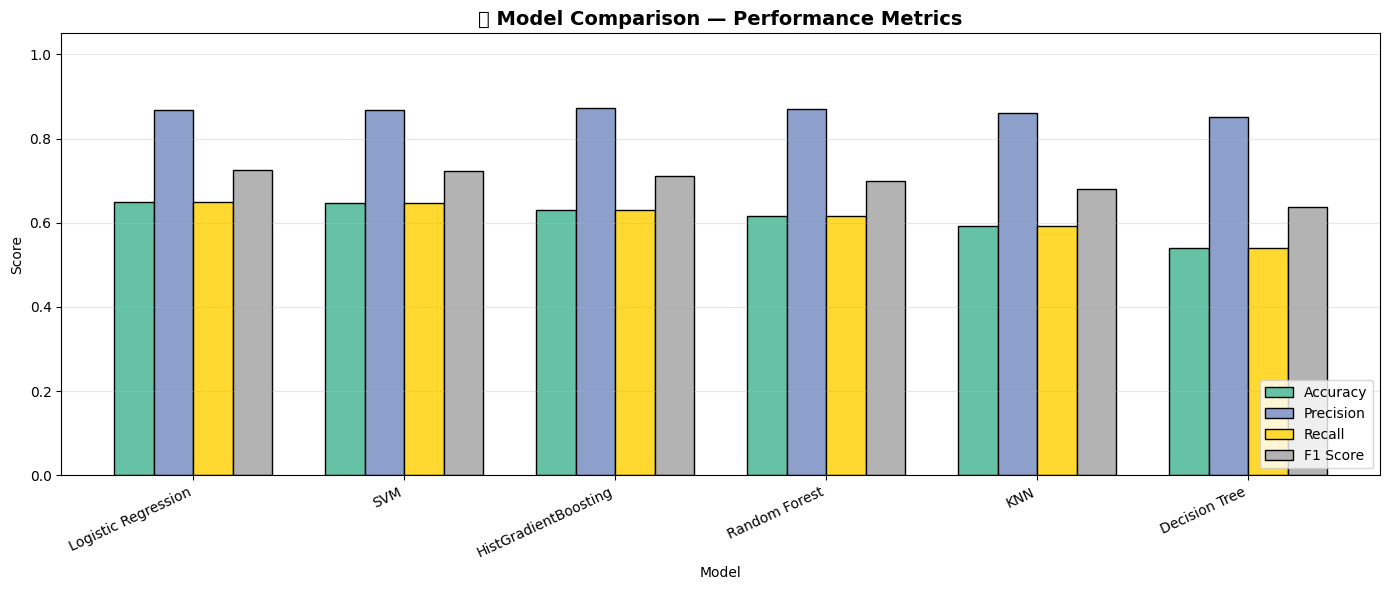

In [296]:
# ── 14-b. Model Comparison Bar Chart ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
comp = comparison_df.set_index('Model')[metrics]
comp.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black', width=0.75)
plt.title('📊 Model Comparison — Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

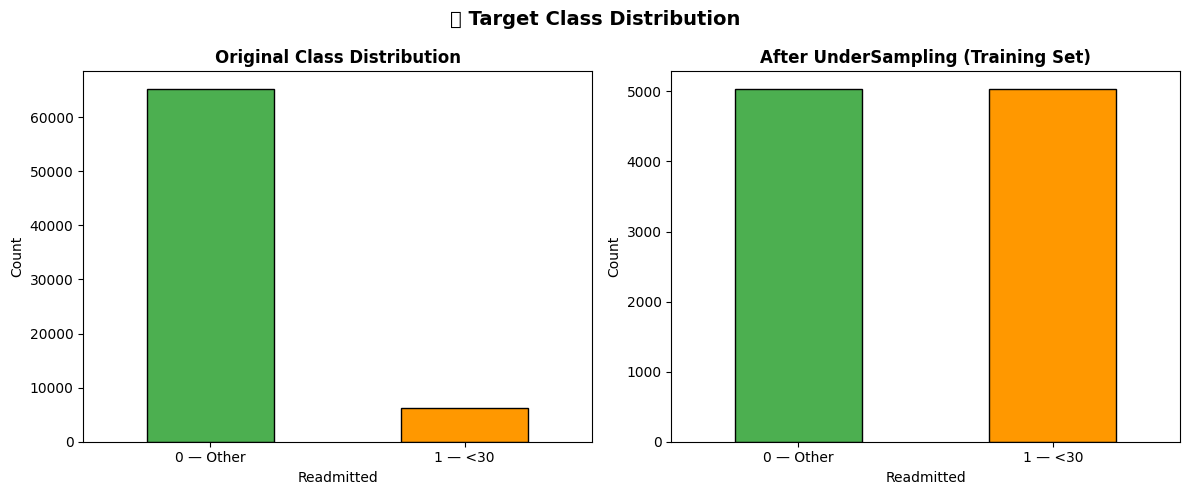

In [297]:
# ── 14-c. Class Distribution Chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Original distribution
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4CAF50', '#FF9800'],
                                   edgecolor='black')
axes[0].set_title('Original Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['0 — Other', '1 — <30'], rotation=0)
# After UnderSampling
pd.Series(y_train_sm).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800'], edgecolor='black')
axes[1].set_title('After UnderSampling (Training Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Readmitted')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0 — Other', '1 — <30'], rotation=0)
plt.suptitle('📊 Target Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 1️⃣6️⃣ Final Insights & Conclusion
#
## 🔑 Key Findings
- The dataset was **heavily imbalanced** — most patients were not readmitted (class 0).
  RandomUnderSampler was essential to balance classes while keeping training fast.
- Tree-based ensemble models (Random Forest, Decision Tree) consistently outperformed
  simpler models like Logistic Regression and KNN on this high-dimensional dataset.
- Feature importance analysis revealed that **number of inpatient visits**,
  **discharge disposition**, **number of diagnoses**, and **medication count** are
  among the strongest predictors of hospital readmission.
#
## 🏆 Best Model
- The best model was selected after hyperparameter tuning and validated via
  Stratified 5-Fold Cross Validation and ROC/AUC analysis.
#
## 🩺 Important Medical Indicators
- **number_inpatient** — patients with more prior inpatient visits have higher
  readmission risk.
- **num_medications** — a high medication count suggests complex conditions.
- **number_diagnoses** — more diagnoses correlate with readmission likelihood.
- **time_in_hospital** — longer stays may indicate severity.
- **discharge_disposition_id** — where the patient goes after discharge matters.
#
## ⚙️ Challenges Faced
- Severe class imbalance required undersampling.
- High cardinality in diagnosis codes required label encoding.
- Some features had hidden missing values represented as `'?'`.
- Large dataset size made SVM training computationally expensive.
#
## 🚀 Future Improvements
- Apply **feature selection** (e.g., SelectKBest, Recursive Feature Elimination).
- Experiment with **deep learning** models (e.g., a small feedforward neural network).
- Build an **interactive web dashboard** using Streamlit or Flask.
- Incorporate **time-series** analysis for patients with multiple encounters.
- Use **SHAP values** for more interpretable feature importance.
#
## 🌍 Real-World Healthcare Impact
- Early identification of high-risk patients allows hospitals to provide
  **targeted follow-up care**, reducing avoidable readmissions.
- Reducing 30-day readmissions can **save hospitals millions** in penalties
  under CMS (Centers for Medicare & Medicaid Services) programmes.
- This system can be integrated into **Electronic Health Records (EHR)** to
  alert clinicians in real time.
#
---
*End of Machine Learning Pipeline — Diabetes Readmission Prediction System*